# 📂Carga de datos

In [8]:
# --- 1. Montaje de Drive y entorno ---
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

DIR_DATA = os.path.join(PATH_REPO, "data_procesada")

# --- 2. Carga del checkpoint de features (todos los sujetos, formato largo) ---
ruta_checkpoint = os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet")
df_check = pd.read_parquet(ruta_checkpoint)

print(f"Checkpoint de features: {df_check.shape}")
print("Sujetos:", df_check['subject_id'].nunique())

df_features_wide = df_check.pivot_table(
    index=['subject_id', 'trial_idx', 'label'],
    columns='feature_col',
    values='valor'
).reset_index()
df_features_wide['Clase_Nombre'] = df_features_wide['label'].map({0: 'Mano Izquierda', 1: 'Mano Derecha'})

print(f"df_features_wide: {df_features_wide.shape}")

# --- 3. Carga de la tabla de estabilidad y detalle por fold (Fase 2) ---
ruta_estabilidad = os.path.join(DIR_DATA, "tabla_estabilidad_features.csv")
tabla_estabilidad_pct = pd.read_csv(ruta_estabilidad, index_col=0)

ruta_seleccion_folds = os.path.join(DIR_DATA, "seleccion_features_por_fold.parquet")
df_seleccion_folds = pd.read_parquet(ruta_seleccion_folds)

print(f"\nTabla de estabilidad: {tabla_estabilidad_pct.shape}")
display(tabla_estabilidad_pct.head())

# --- 4. Carga de las features finales seleccionadas (umbral de consenso) ---
ruta_features_finales = os.path.join(DIR_DATA, "features_finales_seleccionadas.json")
with open(ruta_features_finales, 'r') as f:
    seleccion_guardada = json.load(f)

features_finales = seleccion_guardada['features']
UMBRAL_CONSENSO = seleccion_guardada['umbral_consenso']

print(f"\nFeatures finales cargadas ({len(features_finales)}, umbral={UMBRAL_CONSENSO}%):")
print(features_finales)

# --- 5. Dataset final listo para SVM / Random Forest / PCA+LDA ---
X_final = df_features_wide[features_finales]
y_final = df_features_wide['label']
groups_final = df_features_wide['subject_id']  # para mantener el mismo esquema de split por sujeto

print(f"\nX_final: {X_final.shape} | y_final: {y_final.shape} | Sujetos: {groups_final.nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint de features: (1427400, 5)
Sujetos: 60
df_features_wide: (19032, 79)

Tabla de estabilidad: (72, 5)


,ANOVA,MI,RFE,Lasso,Consenso_Promedio_%
feature,,,,,
power_band_2_C3,100,80,60,100,85.0
AR_coef10_C4,100,20,100,100,80.0
potencia_total_C4,100,20,80,100,75.0
katz_fractal_C4,100,100,0,100,75.0
potencia_total_C3,80,40,80,100,75.0



Features finales cargadas (11, umbral=65%):
['power_band_2_C3', 'AR_coef10_C4', 'potencia_total_C4', 'katz_fractal_C4', 'potencia_total_C3', 'power_band_1_C3', 'entropia_perm_C3', 'AR_coef10_C3', 'power_band_2_C4', 'entropia_perm_C4', 'power_band_3_C4']

X_final: (19032, 11) | y_final: (19032,) | Sujetos: 60


In [9]:
import sys

!pip install mne mne_features antropy statsmodels -q

# --- Setup de entorno (por si esta sesión no lo tiene) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH_DRIVE = '/content/drive/MyDrive'
    REPO_NAME = 'BCI-MENTORIA-UNC'
    PATH_REPO = os.path.join(PATH_DRIVE, REPO_NAME)
    sys.path.append(PATH_REPO)
    os.chdir(PATH_REPO)
    print(f"-> Directorio de trabajo: {os.getcwd()}")
except ImportError:
    print("-> Entorno Local PC.")

import mne
mne.set_log_level('ERROR')
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128

def binarize_y(y):
    unique_classes = np.unique(y)
    assert len(unique_classes) == 2, "y debe tener exactamente dos clases distintas"
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    y_bin = np.vectorize(class_to_bin.get)(y)
    return y_bin, bin_to_class

def binarizar_por_event_id(Y_labels, event_id):
    mapa = {event_id['left_hand']: 0, event_id['right_hand']: 1}
    return np.vectorize(mapa.get)(Y_labels)

# --- 1. lista_sujetos_dreyer ---
lista_sujetos_dreyer = list(df_features_wide['subject_id'].unique())
print(f"lista_sujetos_dreyer: {len(lista_sujetos_dreyer)} sujetos")

# --- 2. dataset_dreyer ---
dataset_dreyer = PreprocessedDataset(
    db_name="Dreyer2023A",
    sessions=SESSIONS,
    subjects=lista_sujetos_dreyer,
    data_to_load=DATA_TO_LOAD,
    channels=CHANNELS,
)
print(f"dataset_dreyer instanciado. Sujetos: {len(dataset_dreyer.get_subjects_list())}")

# --- 3 y 4. L_FREQ_FINAL, H_FREQ_FINAL (banda de consenso de CSP+LDA) ---
# Recargar el consenso desde el df_global de la versión con_banda_y_reg
ruta_global_csp = os.path.join(PATH_REPO, "models", "CSP_LDA", "df_global_CSP_LDA_con_banda_y_reg.csv")
df_global_csp = pd.read_csv(ruta_global_csp)

import ast
config_mas_frecuente = df_global_csp['Best_Params'].mode()[0]
mejores_params_finales = ast.literal_eval(config_mas_frecuente)

N_COMPONENTS_FINAL = mejores_params_finales['csp__n_components']
COMPONENT_ORDER_FINAL = mejores_params_finales['csp__component_order']
REG_FINAL = mejores_params_finales['csp__reg']

BANDAS = {"alfa": (8, 12), "beta": (13, 30), "alfabeta": (8, 30)}
BANDA_FINAL = mejores_params_finales['banda']
L_FREQ_FINAL, H_FREQ_FINAL = BANDAS[BANDA_FINAL]

print(f"\nConsenso CSP+LDA recargado:")
print(f"n_components={N_COMPONENTS_FINAL}, component_order={COMPONENT_ORDER_FINAL}, "
      f"reg={REG_FINAL}, banda={BANDA_FINAL} ({L_FREQ_FINAL}-{H_FREQ_FINAL}Hz)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Directorio de trabajo: /content/drive/MyDrive/BCI-MENTORIA-UNC
lista_sujetos_dreyer: 60 sujetos
dataset_dreyer instanciado. Sujetos: 60

Consenso CSP+LDA recargado:
n_components=4, component_order=mutual_info, reg=ledoit_wolf, banda=alfabeta (8-30Hz)


# 📌 Nota introductoria — Cómo usar esta notebook
Esta notebook contiene el pipeline completo de la Fase 2 (ML clásico): búsqueda de hiperparámetros, reentrenamiento final, métricas obligatorias, permutation tests, filtro de BCI Illiteracy y análisis por género para los 60 sujetos.

No es necesario correr todas las celdas de entrenamiento desde cero. Cada etapa ya guardó sus resultados en disco (checkpoints), por lo que alcanza con ejecutar la celda de carga de checkpoints (al inicio de esta sección) para recuperar todas las variables y dataframes necesarios — sin repetir GridSearchCV, reentrenamientos, permutation tests ni simulaciones online, que son los pasos más costosos en tiempo de todo el proyecto.

Lo que sí hay que volver a ejecutar son las celdas de visualización (plt.show()) de cada gráfico puntual que quieras ver — estas son rápidas (segundos), ya que solo grafican datos que la celda de carga ya trajo, sin recalcular nada.

En resumen:

Corré la celda de carga de checkpoints (una sola vez).
Corré únicamente la/las celdas de gráfico que te interese visualizar.
Solo si necesitás modificar algún hiperparámetro, agregar un sujeto nuevo, o cambiar algo del pipeline en sí, hace falta volver a las celdas de entrenamiento originales.

In [10]:
# ============================================================================
# CARGA COMPLETA DE CHECKPOINTS — Fase 2.1 ML
# Organizada por etapa, para no tener que re-ejecutar las 116 celdas
# ============================================================================
import os, sys, json, ast, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# ETAPA 0 — Entorno (Drive, mne, PreprocessedDataset, funciones base)
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH_DRIVE = '/content/drive/MyDrive'
    PATH_REPO = os.path.join(PATH_DRIVE, 'BCI-MENTORIA-UNC')
    sys.path.append(PATH_REPO)
    os.chdir(PATH_REPO)
except ImportError:
    PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
DIR_DATA = os.path.join(PATH_REPO, "data_procesada")

import mne
mne.set_log_level('ERROR')
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

def binarize_y(y):
    unique_classes = np.unique(y)
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    return np.vectorize(class_to_bin.get)(y), bin_to_class

def binarizar_por_event_id(Y_labels, event_id):
    mapa = {event_id['left_hand']: 0, event_id['right_hand']: 1}
    return np.vectorize(mapa.get)(Y_labels)

def within_subject_online_simulated(n_trials, n_splits=5, train_ratio=0.5):
    indices = np.arange(n_trials)
    splits = []
    inicio_test = int(n_trials * train_ratio)
    tam_bloque_test = (n_trials - inicio_test) // n_splits
    for i in range(n_splits):
        fin_test = inicio_test + tam_bloque_test * (i + 1)
        train_idx = indices[:inicio_test + tam_bloque_test * i]
        test_idx = indices[inicio_test + tam_bloque_test * i : fin_test]
        if len(test_idx) == 0:
            continue
        splits.append((train_idx, test_idx))
    return splits

print("✅ ETAPA 0 — Entorno listo")

# ----------------------------------------------------------------------------
# ETAPA 1 — Features (Fase 1/2) + dataset Dreyer + consenso CSP (banda/reg)
# ----------------------------------------------------------------------------
try:
    df_check = pd.read_parquet(os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet"))
    df_features_wide = df_check.pivot_table(
        index=['subject_id', 'trial_idx', 'label'], columns='feature_col', values='valor'
    ).reset_index()
    df_features_wide['Clase_Nombre'] = df_features_wide['label'].map({0: 'Mano Izquierda', 1: 'Mano Derecha'})

    tabla_estabilidad_pct = pd.read_csv(os.path.join(DIR_DATA, "tabla_estabilidad_features.csv"), index_col=0)
    df_seleccion_folds = pd.read_parquet(os.path.join(DIR_DATA, "seleccion_features_por_fold.parquet"))

    with open(os.path.join(DIR_DATA, "features_finales_seleccionadas.json"), 'r') as f:
        seleccion_guardada = json.load(f)
    features_finales = seleccion_guardada['features']
    UMBRAL_CONSENSO = seleccion_guardada['umbral_consenso']

    lista_sujetos_dreyer = list(df_features_wide['subject_id'].unique())
    lista_sujetos = lista_sujetos_dreyer  # alias usado en celdas de CSP

    dataset_dreyer = PreprocessedDataset(db_name="Dreyer2023A", sessions=SESSIONS,
                                          subjects=lista_sujetos_dreyer,
                                          data_to_load=DATA_TO_LOAD, channels=CHANNELS)
    dataset = dataset_dreyer  # alias usado en celdas viejas de CSP (sin_banda_sin_reg)

    # Consenso de hiperparámetros CSP (versión con_banda_y_reg)
    df_global_csp = pd.read_csv(os.path.join(PATH_REPO, "models", "CSP_LDA",
                                              "df_global_CSP_LDA_con_banda_y_reg.csv"))
    mejores_params_finales = ast.literal_eval(df_global_csp['Best_Params'].mode()[0])
    N_COMPONENTS_FINAL = mejores_params_finales['csp__n_components']
    COMPONENT_ORDER_FINAL = mejores_params_finales['csp__component_order']
    REG_FINAL = mejores_params_finales['csp__reg']
    BANDAS = {"alfa": (8, 12), "beta": (13, 30), "alfabeta": (8, 30)}
    BANDA_FINAL = mejores_params_finales['banda']
    L_FREQ_FINAL, H_FREQ_FINAL = BANDAS[BANDA_FINAL]

    print(f"✅ ETAPA 1 — features_finales ({len(features_finales)}), "
          f"{len(lista_sujetos_dreyer)} sujetos, banda CSP={BANDA_FINAL} ({L_FREQ_FINAL}-{H_FREQ_FINAL}Hz)")
except Exception as e:
    print(f"⚠️ ETAPA 1 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 2 — Resultados por modelo ML (global + final + hiperparámetros)
# ----------------------------------------------------------------------------
try:
    df_global_svm     = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_global_SVM.csv"))
    df_global_dt      = pd.read_csv(os.path.join(PATH_REPO, "models", "DecisionTree", "df_global_DecisionTree.csv"))
    df_global_rf      = pd.read_csv(os.path.join(PATH_REPO, "models", "RandomForest", "df_global_RandomForest.csv"))
    df_global_pca_lda = pd.read_csv(os.path.join(PATH_REPO, "models", "PCA_LDA", "df_global_PCA_LDA.csv"))

    df_final_svm     = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv"))
    df_final_dt      = pd.read_csv(os.path.join(PATH_REPO, "models", "DecisionTree", "df_final_DecisionTree.csv"))
    df_final_rf      = pd.read_csv(os.path.join(PATH_REPO, "models", "RandomForest", "df_final_RandomForest.csv"))
    df_final_pca_lda = pd.read_csv(os.path.join(PATH_REPO, "models", "PCA_LDA", "df_final_PCA_LDA.csv"))

    # Hiperparámetros de consenso, por modelo (para reconstruir pipelines sin GridSearch)
    params_svm     = ast.literal_eval(df_global_svm['Best_Params'].mode()[0])
    params_dt      = ast.literal_eval(df_global_dt['Best_Params'].mode()[0])
    params_rf      = ast.literal_eval(df_global_rf['Best_Params'].mode()[0])
    params_pca_lda = ast.literal_eval(df_global_pca_lda['Best_Params'].mode()[0])

    C_FINAL, KERNEL_FINAL = params_svm['clf__C'], params_svm['clf__kernel']
    MAX_DEPTH_FINAL = params_dt['clf__max_depth']
    MIN_SAMPLES_SPLIT_FINAL = params_dt['clf__min_samples_split']
    CRITERION_FINAL = params_dt['clf__criterion']
    N_ESTIMATORS_FINAL = params_rf['clf__n_estimators']
    SOLVER_FINAL = params_pca_lda['clf__solver']

    print(f"✅ ETAPA 2 — SVM/DecisionTree/RandomForest/PCA_LDA (global + final + hiperparámetros)")
except Exception as e:
    print(f"⚠️ ETAPA 2 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 3 — CSP+LDA final (versión con_banda_y_reg — la corregida)
# ----------------------------------------------------------------------------
try:
    df_final_csp = pd.read_csv(os.path.join(PATH_REPO, "models", "CSP_LDA",
                                             "df_final_CSP_LDA_con_banda_y_reg.csv"))
    assert df_final_csp['Version'].iloc[0] == "con_banda_y_reg"
    print("✅ ETAPA 3 — df_final_csp (con_banda_y_reg) verificado")
except Exception as e:
    print(f"⚠️ ETAPA 3 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 4 — Métricas obligatorias completas (Accuracy/Precision/Recall/F1/AUC-ROC)
# ----------------------------------------------------------------------------
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)

def cargar_modelo(model_name, version_folder, subject_id):
    if version_folder:
        ruta = os.path.join(PATH_REPO, "models", model_name, version_folder,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    else:
        ruta = os.path.join(PATH_REPO, "models", model_name,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    with open(ruta, 'rb') as f:
        return pickle.load(f)

def calcular_metricas_completas(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    try:
        y_score = modelo.decision_function(X_test) if hasattr(modelo, 'decision_function') \
            else modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = np.nan
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    return {'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'auc_roc': auc, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

try:
    df_metricas_completas = pd.read_csv(os.path.join(PATH_REPO, "models", "comparaciones",
                                                       "metricas_completas_ML.csv"))
    print(f"✅ ETAPA 4 — df_metricas_completas: {df_metricas_completas.groupby('modelo').size().to_dict()}")
except Exception as e:
    print(f"⚠️ ETAPA 4 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 5 — Comparación CV entre los 4 modelos ML (tabla_resultados)
# ----------------------------------------------------------------------------
try:
    df_comparacion_cv = pd.read_csv(os.path.join(PATH_REPO, "resultados", "checkpoint_comparacion_cv.csv"))
    tabla_resultados = pd.read_csv(os.path.join(PATH_REPO, "resultados", "checkpoint_tabla_resultados.csv"),
                                    index_col=0)
    print("✅ ETAPA 5 — df_comparacion_cv / tabla_resultados")
except Exception as e:
    print(f"⚠️ ETAPA 5 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 6 — Permutation test (SVM) y (CSP+LDA)
# ----------------------------------------------------------------------------
try:
    df_pvalue_svm = pd.read_csv(os.path.join(PATH_REPO, "resultados", "checkpoint_pvalue_svm.csv"))
    print(f"✅ ETAPA 6a — df_pvalue_svm ({len(df_pvalue_svm)} sujetos)")
except Exception as e:
    print(f"⚠️ ETAPA 6a incompleta: {e}")

try:
    df_permutation = pd.read_csv(os.path.join(PATH_REPO, "models", "bci_illiteracy",
                                               "permutation_test_por_sujeto.csv"))
    print(f"✅ ETAPA 6b — df_permutation (CSP+LDA, {len(df_permutation)} sujetos)")
except Exception as e:
    print(f"⚠️ ETAPA 6b incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 7 — Simulación online (within_subject_online_simulated, SVM)
# ----------------------------------------------------------------------------
try:
    MODEL_NAME_ONLINE = "SVM"
    DIR_VALIDACION_ONLINE = os.path.join(PATH_REPO, "models", "validacion_online")
    df_online_todos_v2 = pd.read_csv(os.path.join(
        DIR_VALIDACION_ONLINE, f"online_splits_{MODEL_NAME_ONLINE}_con_metricas_completas.csv"))
    df_online_por_sujeto_v2 = pd.read_csv(os.path.join(
        DIR_VALIDACION_ONLINE, f"online_resumen_por_sujeto_{MODEL_NAME_ONLINE}_metricas_completas.csv"))
    print(f"✅ ETAPA 7 — simulación online ({len(df_online_por_sujeto_v2)} sujetos)")
except Exception as e:
    print(f"⚠️ ETAPA 7 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 8 — Verificación de Data Leakage
# ----------------------------------------------------------------------------
try:
    df_verificacion = pd.read_csv(os.path.join(DIR_VALIDACION_ONLINE, "verificacion_data_leakage.csv"))
    print("✅ ETAPA 8 — df_verificacion (Data Leakage)")
except Exception as e:
    print(f"⚠️ ETAPA 8 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 9 — Filtro de BCI Illiteracy (umbral binomial)
# ----------------------------------------------------------------------------
try:
    DIR_BCI_ILLITERACY = os.path.join(PATH_REPO, "models", "bci_illiteracy")
    tabla_alpha = pd.read_csv(os.path.join(DIR_BCI_ILLITERACY, "tabla_referencia_alpha.csv"))
    df_umbral_sujetos = pd.read_csv(os.path.join(DIR_BCI_ILLITERACY, "umbral_aptitud_por_sujeto.csv"))
    ALPHA_FINAL = 0.05

    from scipy.stats import binom
    def calcular_umbral_binomial(N, p=0.5, alpha=0.05):
        for k in range(0, N + 1):
            if binom.sf(k - 1, N, p) <= alpha:
                return k, k / N
        return N, 1.0

    print(f"✅ ETAPA 9 — BCI Illiteracy ({(~df_umbral_sujetos['Apto_BCI']).mean()*100:.1f}% illiterate)")
except Exception as e:
    print(f"⚠️ ETAPA 9 incompleta: {e}")

resultados_umbral_cv = []
for _, row in df_final_csp.iterrows():
    sujeto_id = row['subject_id']
    n_trials_sujeto = len(df_features_wide[df_features_wide['subject_id'] == sujeto_id])
    n_train_total = int(n_trials_sujeto * (1 - SPLIT_TEST_SIZE))
    N_test_cv = n_train_total // K_FOLDS
    k, umbral_acc = calcular_umbral_binomial(N_test_cv, p=0.5, alpha=ALPHA_FINAL)
    resultados_umbral_cv.append({
        'subject_id': sujeto_id, 'CV_Accuracy': row['CV_Accuracy'],
        'umbral_accuracy': umbral_acc, 'Apto_BCI_CV': row['CV_Accuracy'] >= umbral_acc
    })
df_umbral_cv = pd.DataFrame(resultados_umbral_cv)

# ----------------------------------------------------------------------------
# ETAPA 10 — Comparación SVM vs CSP+LDA (CV + métricas completas + Wilcoxon)
# ----------------------------------------------------------------------------
try:
    DIR_COMPARACIONES = os.path.join(PATH_REPO, "models", "comparaciones")
    df_comparacion_svm_csp = pd.read_csv(os.path.join(DIR_COMPARACIONES, "comparativa_SVM_vs_CSPLDA_wide.csv"))
    resumen = pd.read_csv(os.path.join(DIR_COMPARACIONES, "resumen_promedio_SVM_vs_CSPLDA.csv"), index_col=0)
    df_comparacion_svm_csp_completas = pd.read_csv(os.path.join(
        DIR_COMPARACIONES, "comparativa_SVM_vs_CSPLDA_metricas_completas.csv"))
    df_wilcoxon_completas = pd.read_csv(os.path.join(
        DIR_COMPARACIONES, "wilcoxon_SVM_vs_CSPLDA_metricas_completas.csv"))
    print("✅ ETAPA 10 — comparaciones SVM vs CSP+LDA")
except Exception as e:
    print(f"⚠️ ETAPA 10 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 11 — Análisis por género (metadata + resultados + features)
# ----------------------------------------------------------------------------
try:
    mapeo_genero = {1: 'Male', 2: 'Female'}
    metadata_individual = dataset.metadata['subjects_individual_metadata']
    df_metadata = pd.DataFrame([
        {'subject_id': int(sid), 'genero': mapeo_genero[d['SUJ_gender']]}
        for sid, d in metadata_individual.items()
    ])

    columnas_metricas = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
    df_genero_svm = df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][
        ['subject_id'] + columnas_metricas].merge(df_metadata, on='subject_id', how='left')
    df_genero_svm['Modelo'] = 'SVM'
    df_genero_csp = df_metricas_completas[df_metricas_completas['modelo'] == 'CSP_LDA'][
        ['subject_id'] + columnas_metricas].merge(df_metadata, on='subject_id', how='left')
    df_genero_csp['Modelo'] = 'CSP_LDA'
    df_genero_todos = pd.concat([df_genero_svm, df_genero_csp], ignore_index=True)

    df_features_por_sujeto = df_features_wide.groupby('subject_id')[features_finales].mean().reset_index()
    df_features_genero = df_features_por_sujeto.merge(df_metadata, on='subject_id', how='left')

    print(f"✅ ETAPA 11 — género ({df_metadata['genero'].value_counts().to_dict()})")
except Exception as e:
    print(f"⚠️ ETAPA 11 incompleta: {e}")

print("\n🏁 Carga de checkpoints finalizada.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ETAPA 0 — Entorno listo
✅ ETAPA 1 — features_finales (11), 60 sujetos, banda CSP=alfabeta (8-30Hz)
✅ ETAPA 2 — SVM/DecisionTree/RandomForest/PCA_LDA (global + final + hiperparámetros)
✅ ETAPA 3 — df_final_csp (con_banda_y_reg) verificado
✅ ETAPA 4 — df_metricas_completas: {'CSP_LDA': 60, 'DecisionTree': 60, 'PCA_LDA': 60, 'RandomForest': 60, 'SVM': 60}
✅ ETAPA 5 — df_comparacion_cv / tabla_resultados
✅ ETAPA 6a — df_pvalue_svm (60 sujetos)
✅ ETAPA 6b — df_permutation (CSP+LDA, 5 sujetos)
✅ ETAPA 7 — simulación online (60 sujetos)
✅ ETAPA 8 — df_verificacion (Data Leakage)
✅ ETAPA 9 — BCI Illiteracy (55.0% illiterate)
✅ ETAPA 10 — comparaciones SVM vs CSP+LDA
✅ ETAPA 11 — género ({'Male': 30, 'Female': 30})

🏁 Carga de checkpoints finalizada.


## 🔗 Recap Metodológico de Machine Learning

Antes de ejecutar las celdas de entrenamiento de cada modelo, discutan en grupo y respondan de forma sintética las siguientes preguntas guía en su informe:

1. **¿Por qué es estrictamente necesario separar el conjunto de test (Hold-out) del conjunto de entrenamiento ANTES de realizar cualquier optimización?**

    - Es necesario realizar la partición de los datos para que el test sea una medición honesta de datos nunca vistos. Si se lo usa (aunque sea indirectamente) durante la optimización de hiperparámetros, hay data leakage y el resultado final queda influenciado positivamente.


2. **¿Qué son los hiperparámetros de un modelo y en qué se diferencian de los parámetros del mismop?**

    - Los parámetros, se aprenden del dato en .fit() (ej. coeficientes internos de SVC). Mientras que, los hiperparámetros se fijan antes de entrenar y controlan el aprendizaje (ej. C, para ajustar el nivel de regularización en Lasso - el Kernel en SVM). No se aprenden de los datos.

3. **¿De qué forma la Validación Cruzada (K-Fold) nos asegura una selección de hiperparámetros adecuada en comparación con evaluar directamente sobre el conjunto de test?**

    - El K-Fold asegura una mejor elecciónde hiperparámetros porque este parte el entrenamiento en K pedacitos (por ejemplo 5), y cada configuración se prueba entrenando con 4 partes y validando con la que quedó afuera, repitiendo esto 5 veces y promediando los resultados. Así se elige la mejor configuración probándola de varias formas distintas, sin que el modelo vea nunca el test (que queda intacto para usarse al final como una medición real y honesta del rendimiento). En cambio, si se prueba cada opción (hiperparámetro) directamente sobre el test el resultado si bien podría parecer óptimo, este no serviría con datos nuevos (nunca antes vistos) puesto que está ajustado a la elección hecha inicialmente.


4. **¿Qué métodos conocen para determinar qué características son las más discriminativas (Feature Selection) antes de entrenar?¿En que parte del pipeline se implementa?** *(No es necesario implementarlo en código, solo describan la lógica teórica).*

    - Existen distintas formas para determinar qué feature ayudar a discriminar mejor antes de implemnetar el modelado. Dentro de las cuales podemos destacar:

          a. Filtro: métricas estadísticas (correlación, ANOVA, información mutua).

          b. Selección basada en Eliminación Recursiva de Características (RFE)
          
          c. Selección durante el entrenamiento (Lasso, importancia de features en árboles, o PCA) del split (solo con datos de train), idealmente dentro del Pipeline para que se recalcule en cada fold y no haya leakage.

5. **Una vez que la Validación Cruzada encuentra el mejor set de hiperparámetros para un sujeto: ¿Qué hacemos con esos hiperparámetros antes de evaluar el rendimiento final en el conjunto de Test?**

    -  Una vez encontrados los hiperparámetros óptimos mediante CV lo que se hace es reentrenar el modelo desde cero con esos hiperparámetros. Recién ese modelo final se evalúa una sola vez sobre el test.

### 🏛️ Modelo: Máquinas de Vectores de Soporte (SVM)

La SVM busca encontrar un hiperplano óptimo de separación maximizando el margen entre las clases. En esta sección, utilizaremos **Búsqueda en Grilla (GridSearchCV)** combinada con **StratifiedKFold** para explorar sistemáticamente dos configuraciones clave del modelo y seleccionar la mejor arquitectura para cada sujeto.

¿Qué es y como funciona SVM? Detallar

Es un modelo que busca la línea (o frontera) que separa mejor las dos clases, dejando el mayor margen posible entre ellas. Los puntos más cercanos a esa frontera ("vectores de soporte") son los que definen dónde queda la línea.

- C: qué tan estricto es con los errores (alto = margen ajustado, puede sobreajustar; bajo = margen más amplio, generaliza más).
- kernel: si los datos no se separan bien con una recta (linear), se pueden proyectar a más dimensiones (rbf) para encontrar una frontera curva que sí los separe.

##### ENTRENAMIENTO DE SVM (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)

In [ ]:
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

MODEL_NAME1 = "SVM"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME1)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

# Lista para armar el DataFrame global exclusivo de este modelo
metricas_globales_svm = []

# DEFINICIÓN DE LA GRILLA
grid_parametros = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__kernel": ["linear", "rbf"]
}

# DEFINICIÓN DE LOS PARÁMETROS DE SPLIT
RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

# Iteramos sujeto por sujeto (Esquema Sujeto-Dependiente)
for sujeto_id in df_features_wide['subject_id'].unique():
    print(f"\n🚀 Entrenando {MODEL_NAME1} para Sujeto: {sujeto_id}")

    # 1. Aislamiento de datos del sujeto, usando SOLO las features finales seleccionadas
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]

    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    # 2. Split de Seguridad (80/20) Balanceado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    # 3. Pipeline (Escalador + Clasificador)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=RANDOM_SEED))
    ])

    # 4. Búsqueda de Hiperparámetros con K-Fold Balanceado por Clase
    cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    grid_search = GridSearchCV(pipe, param_grid=grid_parametros, cv=cv_estrategia, scoring=SCORING, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # 5. Reentrenamiento Automático y Evaluación en Test
    mejor_modelo = grid_search.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f" -> Mejor configuración CV: {grid_search.best_params_}")
    print(f" -> [TEST] Accuracy: {test_acc:.4f}")

    # 6. PERSISTENCIA EN DISCO
    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)

    ruta_pkl = os.path.join(dir_sujeto, "mejor_modelo.pkl")
    with open(ruta_pkl, 'wb') as f:
        pickle.dump(mejor_modelo, f)

    ruta_json = os.path.join(dir_sujeto, "metricas_hiperparametros.json")
    info_sujeto = {
        "mejor_hiperparametros": grid_search.best_params_,
        "metricas_cv_accuracy": grid_search.best_score_,
        "metricas_test": {"accuracy": test_acc}
    }
    with open(ruta_json, 'w') as f:
        json.dump(info_sujeto, f, indent=4)

    # Acumular datos para el reporte global
    metricas_globales_svm.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME1,
        "Best_Params": str(grid_search.best_params_),
        "CV_Accuracy": grid_search.best_score_,
        "Test_Accuracy": test_acc
    })

# 7. GUARDAR EL DATAFRAME GLOBAL DEL MODELO
df_global_svm = pd.DataFrame(metricas_globales_svm)
ruta_csv_global = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME1}.csv")
df_global_svm.to_csv(ruta_csv_global, index=False)

print(f"\n⭐ Proceso finalizado para {MODEL_NAME1}. Archivo consolidado guardado en: {ruta_csv_global}")
display(df_global_svm)


🚀 Entrenando SVM para Sujeto: 1
 -> Mejor configuración CV: {'clf__C': 10.0, 'clf__kernel': 'rbf'}
 -> [TEST] Accuracy: 0.5938

🚀 Entrenando SVM para Sujeto: 2
 -> Mejor configuración CV: {'clf__C': 0.1, 'clf__kernel': 'linear'}
 -> [TEST] Accuracy: 0.6562

🚀 Entrenando SVM para Sujeto: 3
 -> Mejor configuración CV: {'clf__C': 0.1, 'clf__kernel': 'linear'}
 -> [TEST] Accuracy: 0.5156

🚀 Entrenando SVM para Sujeto: 4
 -> Mejor configuración CV: {'clf__C': 10.0, 'clf__kernel': 'linear'}
 -> [TEST] Accuracy: 0.5938

🚀 Entrenando SVM para Sujeto: 5
 -> Mejor configuración CV: {'clf__C': 0.1, 'clf__kernel': 'linear'}
 -> [TEST] Accuracy: 0.5000

🚀 Entrenando SVM para Sujeto: 6
 -> Mejor configuración CV: {'clf__C': 10.0, 'clf__kernel': 'linear'}
 -> [TEST] Accuracy: 0.5781

🚀 Entrenando SVM para Sujeto: 7
 -> Mejor configuración CV: {'clf__C': 10.0, 'clf__kernel': 'rbf'}
 -> [TEST] Accuracy: 0.4844

🚀 Entrenando SVM para Sujeto: 8
 -> Mejor configuración CV: {'clf__C': 1.0, 'clf__kernel': 

,subject_id,Modelo,Best_Params,CV_Accuracy,Test_Accuracy
0,1,SVM,"{'clf__C': 10.0, 'clf__kernel': 'rbf'}",0.660030,0.593750
1,2,SVM,"{'clf__C': 0.1, 'clf__kernel': 'linear'}",0.582202,0.656250
2,3,SVM,"{'clf__C': 0.1, 'clf__kernel': 'linear'}",0.691327,0.515625
3,4,SVM,"{'clf__C': 10.0, 'clf__kernel': 'linear'}",0.605053,0.593750
4,5,SVM,"{'clf__C': 0.1, 'clf__kernel': 'linear'}",0.488612,0.500000
5,6,SVM,"{'clf__C': 10.0, 'clf__kernel': 'linear'}",0.644495,0.578125
6,7,SVM,"{'clf__C': 10.0, 'clf__kernel': 'rbf'}",0.586048,0.484375
7,8,SVM,"{'clf__C': 1.0, 'clf__kernel': 'rbf'}",0.582278,0.562500
8,9,SVM,"{'clf__C': 10.0, 'clf__kernel': 'rbf'}",0.680241,0.578125
9,10,SVM,"{'clf__C': 10.0, 'clf__kernel': 'linear'}",0.808371,0.687500


In [ ]:
import ast

# 1. Determinar la configuración más frecuente entre los 60 GridSearchCV
config_mas_frecuente = df_global_svm['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos:\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones encontradas:")
display(df_global_svm['Best_Params'].value_counts())

# Convertir el string de vuelta a diccionario para poder usarlo
mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

C_FINAL = mejores_params_finales['clf__C']
KERNEL_FINAL = mejores_params_finales['clf__kernel']

Configuración de hiperparámetros más frecuente entre sujetos:
{'clf__C': 0.1, 'clf__kernel': 'linear'}

Distribución de configuraciones encontradas:


,count
Best_Params,
"{'clf__C': 0.1, 'clf__kernel': 'linear'}",15
"{'clf__C': 10.0, 'clf__kernel': 'linear'}",15
"{'clf__C': 1.0, 'clf__kernel': 'rbf'}",12
"{'clf__C': 1.0, 'clf__kernel': 'linear'}",10
"{'clf__C': 10.0, 'clf__kernel': 'rbf'}",8



Hiperparámetros finales a usar: {'clf__C': 0.1, 'clf__kernel': 'linear'}


##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score

metricas_finales_svm = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    modelo_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=C_FINAL, kernel=KERNEL_FINAL, random_state=RANDOM_SEED))
    ])

    cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    scores_cv = cross_validate(
        modelo_final, X_train, y_train, cv=cv_estrategia,
        scoring=['accuracy', 'f1'], return_train_score=True, n_jobs=-1
    )

    modelo_final.fit(X_train, y_train)
    y_pred_final = modelo_final.predict(X_test)
    test_acc_final = accuracy_score(y_test, y_pred_final)
    test_f1_final = f1_score(y_test, y_pred_final)

    metricas_finales_svm.append({
        "subject_id": sujeto_id,
        "Modelo": "SVM",
        "C_final": C_FINAL,
        "Kernel_final": KERNEL_FINAL,
        "CV_Accuracy": scores_cv['test_accuracy'].mean(),
        "CV_Accuracy_std": scores_cv['test_accuracy'].std(),
        "CV_F1": scores_cv['test_f1'].mean(),
        "Train_Accuracy": scores_cv['train_accuracy'].mean(),
        "Gap_overfitting": scores_cv['train_accuracy'].mean() - scores_cv['test_accuracy'].mean(),
        "Test_Accuracy_Final": test_acc_final,
        "Test_F1_Final": test_f1_final
    })

df_final_svm = pd.DataFrame(metricas_finales_svm)
ruta_csv_final = os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv")
df_final_svm.to_csv(ruta_csv_final, index=False)

print(f"df_final_svm regenerado con columnas: {df_final_svm.columns.tolist()}")

df_final_svm regenerado con columnas: ['subject_id', 'Modelo', 'C_final', 'Kernel_final', 'CV_Accuracy', 'CV_Accuracy_std', 'CV_F1', 'Train_Accuracy', 'Gap_overfitting', 'Test_Accuracy_Final', 'Test_F1_Final']


### 🏛️ Modelo: Árbol de Decisión

##### ENTRENAMIENTO (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)

In [ ]:
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

MODEL_NAME2 = "DecisionTree"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME2)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

metricas_globales_dt = []

# DEFINICIÓN DE LA GRILLA
grid_parametros = {
    "clf__max_depth": [3, 4, 5, 6, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__criterion": ["gini", "entropy"]
}

RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

for sujeto_id in df_features_wide['subject_id'].unique():
    print(f"\n🚀 Entrenando {MODEL_NAME2} para Sujeto: {sujeto_id}")

    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    # Nota: el escalador no es estrictamente necesario para árboles (invariantes a escala),
    # se mantiene en el pipeline solo por consistencia estructural con los demás modelos.
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_SEED))
    ])

    cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    grid_search = GridSearchCV(pipe, param_grid=grid_parametros, cv=cv_estrategia, scoring=SCORING, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    mejor_modelo = grid_search.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f" -> Mejor configuración CV: {grid_search.best_params_}")
    print(f" -> [TEST] Accuracy: {test_acc:.4f}")

    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)

    ruta_pkl = os.path.join(dir_sujeto, "mejor_modelo.pkl")
    with open(ruta_pkl, 'wb') as f:
        pickle.dump(mejor_modelo, f)

    ruta_json = os.path.join(dir_sujeto, "metricas_hiperparametros.json")
    info_sujeto = {
        "mejor_hiperparametros": grid_search.best_params_,
        "metricas_cv_accuracy": grid_search.best_score_,
        "metricas_test": {"accuracy": test_acc}
    }
    with open(ruta_json, 'w') as f:
        json.dump(info_sujeto, f, indent=4)

    metricas_globales_dt.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME2,
        "Best_Params": str(grid_search.best_params_),
        "CV_Accuracy": grid_search.best_score_,
        "Test_Accuracy": test_acc
    })

df_global_dt = pd.DataFrame(metricas_globales_dt)
ruta_csv_global = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME2}.csv")
df_global_dt.to_csv(ruta_csv_global, index=False)

print(f"\n⭐ Proceso finalizado para {MODEL_NAME2}. Archivo consolidado guardado en: {ruta_csv_global}")
display(df_global_dt)


🚀 Entrenando DecisionTree para Sujeto: 1
 -> Mejor configuración CV: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
 -> [TEST] Accuracy: 0.5469

🚀 Entrenando DecisionTree para Sujeto: 2
 -> Mejor configuración CV: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 2}
 -> [TEST] Accuracy: 0.5000

🚀 Entrenando DecisionTree para Sujeto: 3
 -> Mejor configuración CV: {'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
 -> [TEST] Accuracy: 0.6094

🚀 Entrenando DecisionTree para Sujeto: 4
 -> Mejor configuración CV: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 10}
 -> [TEST] Accuracy: 0.4844

🚀 Entrenando DecisionTree para Sujeto: 5
 -> Mejor configuración CV: {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_split': 10}
 -> [TEST] Accuracy: 0.3906

🚀 Entrenando DecisionTree para Sujeto: 6
 -> Mejor configuración CV: {'clf__criterion': 'entropy', 'clf__max_depth': 5,

,subject_id,Modelo,Best_Params,CV_Accuracy,Test_Accuracy
0,1,DecisionTree,"{'clf__criterion': 'gini', 'clf__max_depth': 3...",0.593665,0.546875
1,2,DecisionTree,"{'clf__criterion': 'gini', 'clf__max_depth': 5...",0.546983,0.500000
2,3,DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.617044,0.609375
3,4,DecisionTree,"{'clf__criterion': 'gini', 'clf__max_depth': 5...",0.511916,0.484375
4,5,DecisionTree,"{'clf__criterion': 'gini', 'clf__max_depth': 6...",0.531674,0.390625
5,6,DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.585822,0.531250
6,7,DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.609050,0.578125
7,8,DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.554600,0.468750
8,9,DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.621342,0.593750
9,10,DecisionTree,"{'clf__criterion': 'gini', 'clf__max_depth': 4...",0.707089,0.593750


##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
# --- FIX: fijar explícitamente la carpeta de este modelo, sin depender de que quede seteada de una celda anterior ---
MODEL_NAME2 = "DecisionTree"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME2)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

# 1. Determinar la configuración más frecuente entre los 60 GridSearchCV
config_mas_frecuente = df_global_dt['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos:\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones encontradas:")
display(df_global_dt['Best_Params'].value_counts())

import ast
mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

MAX_DEPTH_FINAL = mejores_params_finales['clf__max_depth']
MIN_SAMPLES_SPLIT_FINAL = mejores_params_finales['clf__min_samples_split']
CRITERION_FINAL = mejores_params_finales['clf__criterion']

metricas_finales_dt = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    modelo_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(
            max_depth=MAX_DEPTH_FINAL,
            min_samples_split=MIN_SAMPLES_SPLIT_FINAL,
            criterion=CRITERION_FINAL,
            random_state=RANDOM_SEED
        ))
    ])
    modelo_final.fit(X_train, y_train)

    y_pred_final = modelo_final.predict(X_test)
    test_acc_final = accuracy_score(y_test, y_pred_final)

    metricas_finales_dt.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME2,
        "Max_Depth_final": MAX_DEPTH_FINAL,
        "Min_Samples_Split_final": MIN_SAMPLES_SPLIT_FINAL,
        "Criterion_final": CRITERION_FINAL,
        "Test_Accuracy_Final": test_acc_final
    })

    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)
    ruta_pkl_final = os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl")
    with open(ruta_pkl_final, 'wb') as f:
        pickle.dump(modelo_final, f)

df_final_dt = pd.DataFrame(metricas_finales_dt)

ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME2}.csv")
df_final_dt.to_csv(ruta_csv_final, index=False)

print(f"\n⭐ Modelos reentrenados con hiperparámetros fijos (max_depth={MAX_DEPTH_FINAL}, min_samples_split={MIN_SAMPLES_SPLIT_FINAL}, criterion='{CRITERION_FINAL}')")
print(f"Accuracy promedio (test, 60 sujetos): {df_final_dt['Test_Accuracy_Final'].mean():.4f} ± {df_final_dt['Test_Accuracy_Final'].std():.4f}")
display(df_final_dt)

Configuración de hiperparámetros más frecuente entre sujetos:
{'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_split': 2}

Distribución de configuraciones encontradas:


,count
Best_Params,
"{'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_split': 2}",6
"{'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 5}",6
"{'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_split': 2}",6
"{'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 10}",4
"{'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_split': 10}",3
"{'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_split': 2}",3
"{'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_split': 2}",3
"{'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_split': 10}",3
"{'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 2}",3



Hiperparámetros finales a usar: {'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_split': 2}

⭐ Modelos reentrenados con hiperparámetros fijos (max_depth=4, min_samples_split=2, criterion='entropy')
Accuracy promedio (test, 60 sujetos): 0.5722 ± 0.0979


,subject_id,Modelo,Max_Depth_final,Min_Samples_Split_final,Criterion_final,Test_Accuracy_Final
0,1,DecisionTree,4,2,entropy,0.578125
1,2,DecisionTree,4,2,entropy,0.546875
2,3,DecisionTree,4,2,entropy,0.484375
3,4,DecisionTree,4,2,entropy,0.562500
4,5,DecisionTree,4,2,entropy,0.453125
5,6,DecisionTree,4,2,entropy,0.531250
6,7,DecisionTree,4,2,entropy,0.562500
7,8,DecisionTree,4,2,entropy,0.468750
8,9,DecisionTree,4,2,entropy,0.578125
9,10,DecisionTree,4,2,entropy,0.562500


### 🏛️ Modelo: Random Forest

##### ENTRENAMIENTO (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)

In [ ]:
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

MODEL_NAME3 = "RandomForest"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME3)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

metricas_globales_rf = []

# DEFINICIÓN DE LA GRILLA
grid_parametros = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [4, 6, None],
    "clf__min_samples_split": [2, 5]
}

RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

for sujeto_id in df_features_wide['subject_id'].unique():
    print(f"\n🚀 Entrenando {MODEL_NAME3} para Sujeto: {sujeto_id}")

    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_SEED))
    ])

    cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    grid_search = GridSearchCV(pipe, param_grid=grid_parametros, cv=cv_estrategia, scoring=SCORING, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    mejor_modelo = grid_search.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f" -> Mejor configuración CV: {grid_search.best_params_}")
    print(f" -> [TEST] Accuracy: {test_acc:.4f}")

    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)

    ruta_pkl = os.path.join(dir_sujeto, "mejor_modelo.pkl")
    with open(ruta_pkl, 'wb') as f:
        pickle.dump(mejor_modelo, f)

    ruta_json = os.path.join(dir_sujeto, "metricas_hiperparametros.json")
    info_sujeto = {
        "mejor_hiperparametros": grid_search.best_params_,
        "metricas_cv_accuracy": grid_search.best_score_,
        "metricas_test": {"accuracy": test_acc}
    }
    with open(ruta_json, 'w') as f:
        json.dump(info_sujeto, f, indent=4)

    metricas_globales_rf.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME3,
        "Best_Params": str(grid_search.best_params_),
        "CV_Accuracy": grid_search.best_score_,
        "Test_Accuracy": test_acc
    })

df_global_rf = pd.DataFrame(metricas_globales_rf)
ruta_csv_global = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME3}.csv")
df_global_rf.to_csv(ruta_csv_global, index=False)

print(f"\n⭐ Proceso finalizado para {MODEL_NAME3}. Archivo consolidado guardado en: {ruta_csv_global}")
display(df_global_rf)


🚀 Entrenando RandomForest para Sujeto: 1
 -> Mejor configuración CV: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
 -> [TEST] Accuracy: 0.6094

🚀 Entrenando RandomForest para Sujeto: 2
 -> Mejor configuración CV: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
 -> [TEST] Accuracy: 0.5625

🚀 Entrenando RandomForest para Sujeto: 3
 -> Mejor configuración CV: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
 -> [TEST] Accuracy: 0.5781

🚀 Entrenando RandomForest para Sujeto: 4
 -> Mejor configuración CV: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
 -> [TEST] Accuracy: 0.5156

🚀 Entrenando RandomForest para Sujeto: 5
 -> Mejor configuración CV: {'clf__max_depth': 6, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
 -> [TEST] Accuracy: 0.5000

🚀 Entrenando RandomForest para Sujeto: 6
 -> Mejor configuración CV: {'clf__max_depth': 6, 'clf__min_samples_spl

KeyboardInterrupt: 

##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
# 1. Determinar la configuración más frecuente entre los 60 GridSearchCV
config_mas_frecuente = df_global_rf['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos:\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones encontradas:")
display(df_global_rf['Best_Params'].value_counts())

# Convertir el string de vuelta a diccionario para poder usarlo
import ast
mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

N_ESTIMATORS_FINAL = mejores_params_finales['clf__n_estimators']
MAX_DEPTH_FINAL = mejores_params_finales['clf__max_depth']
MIN_SAMPLES_SPLIT_FINAL = mejores_params_finales['clf__min_samples_split']

# 2. Reentrenar CADA sujeto desde cero, con esta ÚNICA configuración fija
#    (sin GridSearchCV: se fitea directo con el train, se evalúa una sola vez con el test)
metricas_finales_rf = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    modelo_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=N_ESTIMATORS_FINAL,
            max_depth=MAX_DEPTH_FINAL,
            min_samples_split=MIN_SAMPLES_SPLIT_FINAL,
            random_state=RANDOM_SEED
        ))
    ])
    modelo_final.fit(X_train, y_train)

    y_pred_final = modelo_final.predict(X_test)
    test_acc_final = accuracy_score(y_test, y_pred_final)

    metricas_finales_rf.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME3,
        "N_Estimators_final": N_ESTIMATORS_FINAL,
        "Max_Depth_final": MAX_DEPTH_FINAL,
        "Min_Samples_Split_final": MIN_SAMPLES_SPLIT_FINAL,
        "Test_Accuracy_Final": test_acc_final
    })

    # Guardar el modelo final reentrenado (sobreescribe el de la grilla individual)
    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)
    ruta_pkl_final = os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl")
    with open(ruta_pkl_final, 'wb') as f:
        pickle.dump(modelo_final, f)

df_final_rf = pd.DataFrame(metricas_finales_rf)

# 3. Guardar el reporte global de la versión final
ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME3}.csv")
df_final_rf.to_csv(ruta_csv_final, index=False)

print(f"\n⭐ Modelos reentrenados con hiperparámetros fijos (n_estimators={N_ESTIMATORS_FINAL}, max_depth={MAX_DEPTH_FINAL}, min_samples_split={MIN_SAMPLES_SPLIT_FINAL})")
print(f"Accuracy promedio (test, 60 sujetos): {df_final_rf['Test_Accuracy_Final'].mean():.4f} ± {df_final_rf['Test_Accuracy_Final'].std():.4f}")
display(df_final_rf)

#### Visualización


⭐ Modelos reentrenados con hiperparámetros fijos (n_estimators=200, max_depth=4, min_samples_split=2)
Accuracy promedio (test, 60 sujetos): 0.6001 ± 0.1102


,subject_id,Modelo,N_Estimators_final,Max_Depth_final,Min_Samples_Split_final,Test_Accuracy_Final
0,1,RandomForest,200,4,2,0.562500
1,2,RandomForest,200,4,2,0.562500
2,3,RandomForest,200,4,2,0.531250
3,4,RandomForest,200,4,2,0.453125
4,5,RandomForest,200,4,2,0.500000
5,6,RandomForest,200,4,2,0.562500
6,7,RandomForest,200,4,2,0.578125
7,8,RandomForest,200,4,2,0.640625
8,9,RandomForest,200,4,2,0.562500
9,10,RandomForest,200,4,2,0.640625


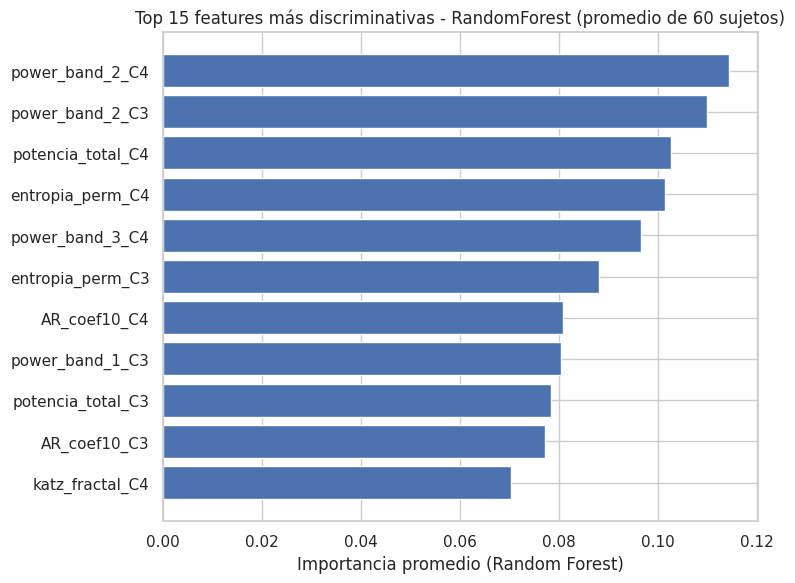

,feature,importancia_media
8,power_band_2_C4,0.114406
0,power_band_2_C3,0.109966
2,potencia_total_C4,0.102554
9,entropia_perm_C4,0.101378
10,power_band_3_C4,0.096503
6,entropia_perm_C3,0.088157
1,AR_coef10_C4,0.080813
5,power_band_1_C3,0.080368
4,potencia_total_C3,0.078436
7,AR_coef10_C3,0.077199


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

MODEL_NAME3 = "RandomForest"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME3)

metricas_finales_rf = []
importancias_por_sujeto = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )
    modelo_final = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=N_ESTIMATORS_FINAL,
            max_depth=MAX_DEPTH_FINAL,
            min_samples_split=MIN_SAMPLES_SPLIT_FINAL,
            random_state=RANDOM_SEED
        ))
    ])
    modelo_final.fit(X_train, y_train)

    # <<< Guardar mportancia de features de este sujeto
    importancias = modelo_final.named_steps["clf"].feature_importances_
    importancias_por_sujeto.append(importancias)

    y_pred_final = modelo_final.predict(X_test)
    test_acc_final = accuracy_score(y_test, y_pred_final)
    metricas_finales_rf.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME3,
        "N_Estimators_final": N_ESTIMATORS_FINAL,
        "Max_Depth_final": MAX_DEPTH_FINAL,
        "Min_Samples_Split_final": MIN_SAMPLES_SPLIT_FINAL,
        "Test_Accuracy_Final": test_acc_final
    })
    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)
    ruta_pkl_final = os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl")
    with open(ruta_pkl_final, 'wb') as f:
        pickle.dump(modelo_final, f)

#visualizacion
df_final_rf = pd.DataFrame(metricas_finales_rf)
ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME3}.csv")
df_final_rf.to_csv(ruta_csv_final, index=False)
print(f"\n⭐ Modelos reentrenados con hiperparámetros fijos (n_estimators={N_ESTIMATORS_FINAL}, max_depth={MAX_DEPTH_FINAL}, min_samples_split={MIN_SAMPLES_SPLIT_FINAL})")
print(f"Accuracy promedio (test, 60 sujetos): {df_final_rf['Test_Accuracy_Final'].mean():.4f} ± {df_final_rf['Test_Accuracy_Final'].std():.4f}")
display(df_final_rf)

# <<< NUEVO: gráfico de importancia de features
import matplotlib.pyplot as plt

importancia_promedio = np.mean(importancias_por_sujeto, axis=0)
df_importancias = pd.DataFrame({
    "feature": features_finales,
    "importancia_media": importancia_promedio
}).sort_values("importancia_media", ascending=False)

plt.figure(figsize=(8, 6))
top_n = df_importancias.head(15)
plt.barh(top_n["feature"][::-1], top_n["importancia_media"][::-1])
plt.xlabel("Importancia promedio (Random Forest)")
plt.title(f"Top 15 features más discriminativas - {MODEL_NAME3} (promedio de {len(importancias_por_sujeto)} sujetos)")
plt.tight_layout()
plt.show()

display(df_importancias)

Observando el orden de importancia que el modelo le fue otorgando a las distintas features y comparándolo con la tabla consenso donde se definieron las mismas, se denota de forma clara que el Random Forest le otorgó pesos distintos a cada una respecto al orden obtenido por tabla. Por ejemplo, el caso de la feature _power_band_2_C4_ en ambas sale como la que más discrimina; sin embargo, esto no sucede así con las segunda variable escogida por Random Forest _power_band_2_C3_ donde la misma en la tabla consenso  ocupa la novena posición.

### 🏛️ Modelo: PCA + LDA

##### ENTRENAMIENTO (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)

In [ ]:
import pickle
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

MODEL_NAME4 = "PCA_LDA"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME4)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

metricas_globales_pca_lda = []

# DEFINICIÓN DE LA GRILLA
# n_components de PCA acotado por la cantidad de features finales disponibles
grid_parametros = {
    "pca__n_components": [2, 3, 5],
    "clf__solver": ["svd", "lsqr"]
}

RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

for sujeto_id in df_features_wide['subject_id'].unique():
    print(f"\n🚀 Entrenando {MODEL_NAME4} para Sujeto: {sujeto_id}")

    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_SEED)),
        ("clf", LinearDiscriminantAnalysis())
    ])

    # Ajustar la grilla de n_components si hay menos features que el máximo propuesto
    max_components = min(len(features_finales), X_train.shape[0])
    grid_parametros_sujeto = {
        "pca__n_components": [c for c in grid_parametros["pca__n_components"] if c <= max_components],
        "clf__solver": grid_parametros["clf__solver"]
    }

    cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    grid_search = GridSearchCV(pipe, param_grid=grid_parametros_sujeto, cv=cv_estrategia, scoring=SCORING, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    mejor_modelo = grid_search.best_estimator_
    y_pred = mejor_modelo.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f" -> Mejor configuración CV: {grid_search.best_params_}")
    print(f" -> [TEST] Accuracy: {test_acc:.4f}")

    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)

    ruta_pkl = os.path.join(dir_sujeto, "mejor_modelo.pkl")
    with open(ruta_pkl, 'wb') as f:
        pickle.dump(mejor_modelo, f)

    ruta_json = os.path.join(dir_sujeto, "metricas_hiperparametros.json")
    info_sujeto = {
        "mejor_hiperparametros": grid_search.best_params_,
        "metricas_cv_accuracy": grid_search.best_score_,
        "metricas_test": {"accuracy": test_acc}
    }
    with open(ruta_json, 'w') as f:
        json.dump(info_sujeto, f, indent=4)

    metricas_globales_pca_lda.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME4,
        "Best_Params": str(grid_search.best_params_),
        "CV_Accuracy": grid_search.best_score_,
        "Test_Accuracy": test_acc
    })

df_global_pca_lda = pd.DataFrame(metricas_globales_pca_lda)
ruta_csv_global = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME4}.csv")
df_global_pca_lda.to_csv(ruta_csv_global, index=False)

print(f"\n⭐ Proceso finalizado para {MODEL_NAME4}. Archivo consolidado guardado en: {ruta_csv_global}")
display(df_global_pca_lda)


🚀 Entrenando PCA_LDA para Sujeto: 1


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/initializers.py:28: UserWarning: Unable to introspect viztracer state: [Errno 107] Transport endpoint is not connected
  warnings.warn(f"Unable to introspect viztracer state: {e}")
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/initializers.py:28: UserWarning: Unable to introspect viztracer state: [Errno 107] Transport endpoint is not connected
  warnings.warn(f"Unable to introspect viztracer state: {e}")


OSError: [Errno 107] Transport endpoint is not connected

##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
# 1. Determinar la configuración más frecuente entre los 60 GridSearchCV
config_mas_frecuente = df_global_pca_lda['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos:\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones encontradas:")
display(df_global_pca_lda['Best_Params'].value_counts())

# Convertir el string de vuelta a diccionario para poder usarlo
import ast
mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

N_COMPONENTS_FINAL = mejores_params_finales['pca__n_components']
SOLVER_FINAL = mejores_params_finales['clf__solver']

# 2. Reentrenar CADA sujeto desde cero, con esta ÚNICA configuración fija
#    (sin GridSearchCV: se fitea directo con el train, se evalúa una sola vez con el test)
#    Nota: si algún sujeto tuviera menos features/muestras que N_COMPONENTS_FINAL,
#    se acota n_components al máximo posible para ese sujeto puntual.
metricas_finales_pca_lda = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    n_components_sujeto = min(N_COMPONENTS_FINAL, X_train.shape[0], X_train.shape[1])

    modelo_final = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components_sujeto, random_state=RANDOM_SEED)),
        ("clf", LinearDiscriminantAnalysis(solver=SOLVER_FINAL))
    ])
    modelo_final.fit(X_train, y_train)

    y_pred_final = modelo_final.predict(X_test)
    test_acc_final = accuracy_score(y_test, y_pred_final)

    metricas_finales_pca_lda.append({
        "subject_id": sujeto_id,
        "Modelo": MODEL_NAME4,
        "N_Components_final": n_components_sujeto,
        "Solver_final": SOLVER_FINAL,
        "Test_Accuracy_Final": test_acc_final
    })

    # Guardar el modelo final reentrenado (sobreescribe el de la grilla individual)
    dir_sujeto = os.path.join(DIR_BASE_MODELO, f"subject_{sujeto_id}")
    os.makedirs(dir_sujeto, exist_ok=True)
    ruta_pkl_final = os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl")
    with open(ruta_pkl_final, 'wb') as f:
        pickle.dump(modelo_final, f)

df_final_pca_lda = pd.DataFrame(metricas_finales_pca_lda)

# 3. Guardar el reporte global de la versión final
ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME4}.csv")
df_final_pca_lda.to_csv(ruta_csv_final, index=False)

print(f"\n⭐ Modelos reentrenados con hiperparámetros fijos (n_components={N_COMPONENTS_FINAL}, solver='{SOLVER_FINAL}')")
print(f"Accuracy promedio (test, 60 sujetos): {df_final_pca_lda['Test_Accuracy_Final'].mean():.4f} ± {df_final_pca_lda['Test_Accuracy_Final'].std():.4f}")
display(df_final_pca_lda)

NameError: name 'df_global_pca_lda' is not defined

### 🎯 Estrategia de Validación (Métricas)

In [11]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

SPLIT_TEST_SIZE = 0.20
RANDOM_SEED = 45
K_FOLDS = 5

def cargar_modelo(model_name, version_folder, subject_id):
    if version_folder:
        ruta = os.path.join(PATH_REPO, "models", model_name, version_folder,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    else:
        ruta = os.path.join(PATH_REPO, "models", model_name,
                             f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    with open(ruta, 'rb') as f:
        return pickle.load(f)

def calcular_metricas_completas(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    try:
        if hasattr(modelo, 'decision_function'):
            y_score = modelo.decision_function(X_test)
        else:
            y_score = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc_roc': auc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

modelos_ml_config = {
    'SVM': {'version_folder': None, 'fuente': 'tabular'},
    'DecisionTree': {'version_folder': None, 'fuente': 'tabular'},
    'RandomForest': {'version_folder': None, 'fuente': 'tabular'},
    'PCA_LDA': {'version_folder': None, 'fuente': 'tabular'},
}

resultados_metricas_completas = []

for model_name, config in modelos_ml_config.items():
    print(f"\n=== Procesando {model_name} ===")

    for sujeto_id in lista_sujetos_dreyer:
        try:
            if config['fuente'] == 'tabular':
                df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
                X = df_sujeto[features_finales].values
                y = df_sujeto['label'].values
            else:
                X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
                y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)
                X_filtrado = mne.filter.filter_data(
                    X_eeg_raw.astype(np.float64), sfreq=SFREQ,
                    l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False
                )
                X, y = X_filtrado, y_labels_bin

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
            )

            modelo = cargar_modelo(model_name, config['version_folder'], sujeto_id)
            metricas = calcular_metricas_completas(modelo, X_test, y_test)
            metricas['modelo'] = model_name
            metricas['subject_id'] = sujeto_id
            resultados_metricas_completas.append(metricas)

        except Exception as e:
            print(f" ❌ Sujeto {sujeto_id}: {e}")
            continue

    print(f"{model_name}: {sum(1 for r in resultados_metricas_completas if r['modelo']==model_name)}/60 sujetos procesados")

df_metricas_completas = pd.DataFrame(resultados_metricas_completas)

ruta_metricas = os.path.join(PATH_REPO, "models", "comparaciones", "metricas_completas_ML.csv")
os.makedirs(os.path.dirname(ruta_metricas), exist_ok=True)
df_metricas_completas.to_csv(ruta_metricas, index=False)

print("\n=== Resumen promedio por modelo ===")
print(df_metricas_completas.groupby('modelo')[['accuracy','precision','recall','f1','auc_roc']].mean().round(4))


=== Procesando SVM ===
SVM: 60/60 sujetos procesados

=== Procesando DecisionTree ===


KeyboardInterrupt: 

#### Tabla Comparativa

In [12]:
import ast
from sklearn.model_selection import cross_validate, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- Reconstruir la configuración final (moda) de cada modelo, a partir de sus df_global_* ---
params_svm     = ast.literal_eval(df_global_svm['Best_Params'].mode()[0])
params_dt      = ast.literal_eval(df_global_dt['Best_Params'].mode()[0])
params_rf      = ast.literal_eval(df_global_rf['Best_Params'].mode()[0])
params_pca_lda = ast.literal_eval(df_global_pca_lda['Best_Params'].mode()[0])

RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# --- Diccionario de pipelines finales (uno por modelo), con hiperparámetros ya fijados ---
def construir_modelos(n_components_pca):
    return {
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(C=params_svm['clf__C'], kernel=params_svm['clf__kernel'], random_state=RANDOM_SEED))
        ]),
        "DecisionTree": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", DecisionTreeClassifier(
                max_depth=params_dt['clf__max_depth'],
                min_samples_split=params_dt['clf__min_samples_split'],
                criterion=params_dt['clf__criterion'],
                random_state=RANDOM_SEED
            ))
        ]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=params_rf['clf__n_estimators'],
                max_depth=params_rf['clf__max_depth'],
                min_samples_split=params_rf['clf__min_samples_split'],
                random_state=RANDOM_SEED
            ))
        ]),
        "PCA_LDA": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components_pca, random_state=RANDOM_SEED)),
            ("clf", LinearDiscriminantAnalysis(solver=params_pca_lda['clf__solver']))
        ]),
    }

# --- Comparación por sujeto: cross_validate de los 4 modelos, SOLO sobre el train de cada sujeto ---
filas_comparacion = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    # Mismo split que usan en el reentrenamiento final (el test queda afuera de esta comparación)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    # n_components de PCA acotado al train de ESTE sujeto en particular
    n_comp_sujeto = min(params_pca_lda['pca__n_components'], X_train.shape[0], X_train.shape[1])
    modelos = construir_modelos(n_comp_sujeto)

    for nombre, modelo in modelos.items():
        scores = cross_validate(
            modelo, X_train, y_train, cv=cv,
            scoring=['accuracy', 'f1'],
            return_train_score=True,
            n_jobs=-1
        )

        filas_comparacion.append({
            "subject_id": sujeto_id,
            "Modelo": nombre,
            "CV_Accuracy": scores['test_accuracy'].mean(),
            "CV_Accuracy_std": scores['test_accuracy'].std(),
            "CV_F1": scores['test_f1'].mean(),
            "Train_Accuracy": scores['train_accuracy'].mean(),
            "Gap_overfitting": scores['train_accuracy'].mean() - scores['test_accuracy'].mean()
        })

df_comparacion_cv = pd.DataFrame(filas_comparacion)

# --- Tabla resumen: promedio de cada métrica por modelo, a través de los 60 sujetos ---
tabla_resultados = df_comparacion_cv.groupby("Modelo")[
    ["CV_Accuracy", "CV_Accuracy_std", "CV_F1", "Train_Accuracy", "Gap_overfitting"]
].mean().sort_values("CV_Accuracy", ascending=False)
tabla_resultados = tabla_resultados.round(4)

print(tabla_resultados)

              CV_Accuracy  CV_Accuracy_std   CV_F1  Train_Accuracy  \
Modelo                                                               
SVM                0.6229           0.0538  0.6158          0.6783   
RandomForest       0.6115           0.0575  0.6082          0.9201   
PCA_LDA            0.5848           0.0566  0.5802          0.6274   
DecisionTree       0.5772           0.0497  0.5457          0.7444   

              Gap_overfitting  
Modelo                         
SVM                    0.0553  
RandomForest           0.3086  
PCA_LDA                0.0426  
DecisionTree           0.1671  


####  Visualizacion de AUC - ROC

SVM: AUC medio=0.6652, std=0.1385 (n=60 sujetos)
DecisionTree: AUC medio=0.5886, std=0.1140 (n=60 sujetos)
RandomForest: AUC medio=0.6394, std=0.1347 (n=60 sujetos)
PCA_LDA: AUC medio=0.6263, std=0.1324 (n=60 sujetos)


IndexError: index 5 is out of bounds for axis 0 with size 4

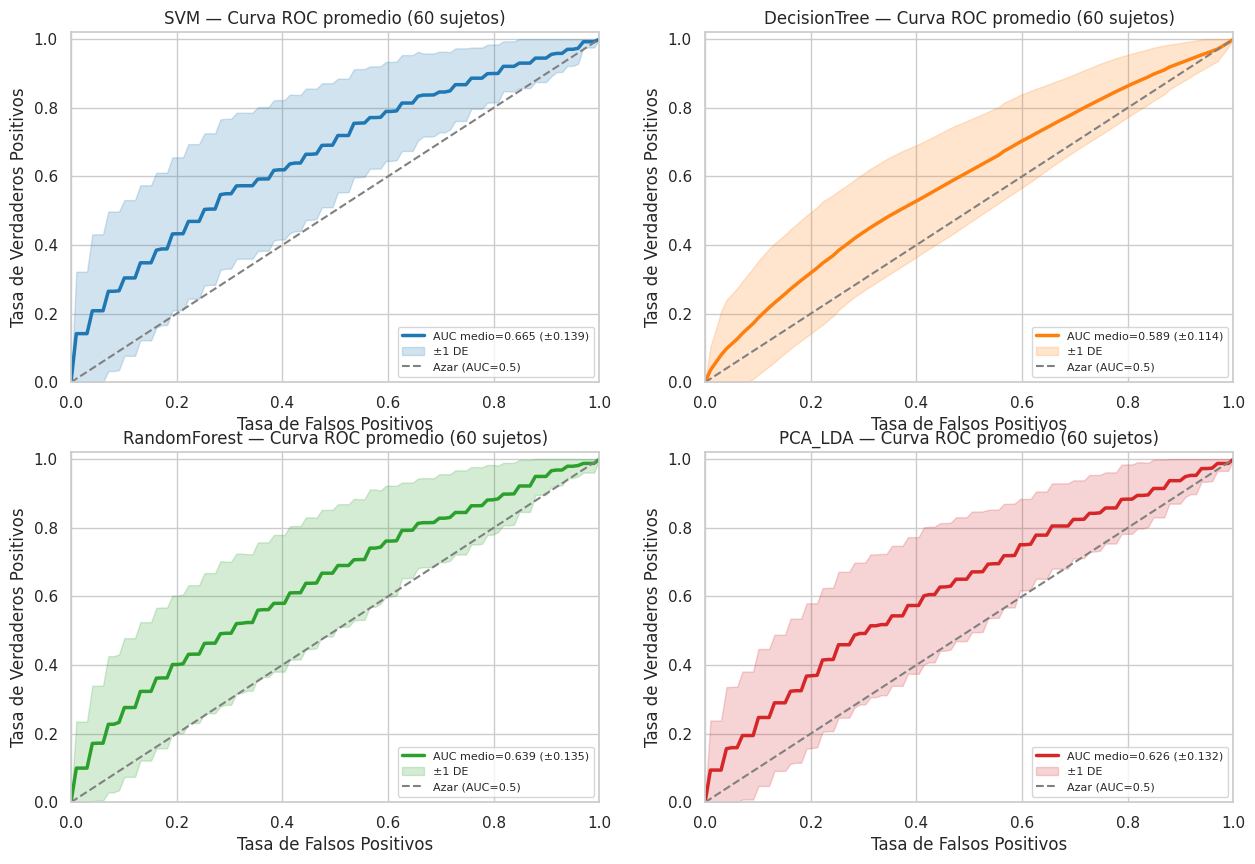

In [13]:
from sklearn.metrics import roc_curve, auc

modelos_a_graficar = {
    'SVM': ('SVM', None, 'tabular'),
    'DecisionTree': ('DecisionTree', None, 'tabular'),
    'RandomForest': ('RandomForest', None, 'tabular'),
    'PCA_LDA': ('PCA_LDA', None, 'tabular')
}

colores = {'SVM': '#1f77b4', 'DecisionTree': '#ff7f0e', 'RandomForest': '#2ca02c',
           'PCA_LDA': '#d62728', 'CSP_LDA': '#9467bd'}

mean_fpr = np.linspace(0, 1, 100)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (nombre, (model_name, version, fuente)) in enumerate(modelos_a_graficar.items()):
    tprs = []
    aucs = []

    for sujeto_id in lista_sujetos_dreyer:
        try:
            if fuente == 'tabular':
                df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
                X = df_sujeto[features_finales].values
                y = df_sujeto['label'].values
            else:
                X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
                y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)
                X = mne.filter.filter_data(X_eeg_raw.astype(np.float64), sfreq=SFREQ,
                                             l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False)
                y = y_labels_bin

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
            )

            modelo = cargar_modelo(model_name, version, sujeto_id)

            if hasattr(modelo, 'decision_function'):
                y_score = modelo.decision_function(X_test)
            else:
                y_score = modelo.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_score)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(auc(fpr, tpr))

        except Exception as e:
            continue

    tprs = np.array(tprs)
    mean_tpr = tprs.mean(axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = tprs.std(axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    ax = axes[i]
    ax.plot(mean_fpr, mean_tpr, color=colores[nombre], linewidth=2.5,
            label=f'AUC medio={mean_auc:.3f} (±{std_auc:.3f})')
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color=colores[nombre], alpha=0.2, label='±1 DE')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(f'{nombre} — Curva ROC promedio (60 sujetos)')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    print(f"{nombre}: AUC medio={mean_auc:.4f}, std={std_auc:.4f} (n={len(aucs)} sujetos)")

axes[5].axis('off')
plt.tight_layout()
plt.show()

#### 1. Lectura breve

SVM muestra la curva más alejada de la diagonal de azar (AUC medio=0.665), confirmando visualmente por qué fue el modelo elegido. su curva se despega claramente por encima de la línea de azar en la mayor parte del rango.

PCA_LDA (AUC=0.626) y DecisionTree (AUC=0.589) muestran las curvas más pegadas a la diagonal. DecisionTree en particular apenas se despega del azar en la primera mitad del rango, consistente con ser el modelo de peor desempeño ya confirmado en la tabla.

Por otra parte las bandas de ±1 desviación estándar son muy anchas (llegando a cruzar el 0 y el 1 en varios tramos) y se superponen entre todos los modelos

###### - BOXPLOTS

/tmp/ipykernel_2169/1754811941.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_metricas_completas, x='modelo', y='auc_roc', showfliers=False, palette='Set2', ax=ax)


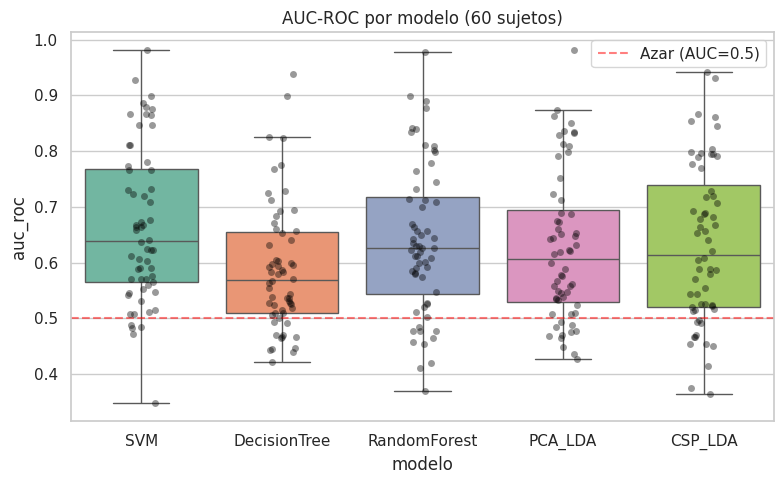

In [14]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_metricas_completas, x='modelo', y='auc_roc', showfliers=False, palette='Set2', ax=ax)
sns.stripplot(data=df_metricas_completas, x='modelo', y='auc_roc', color='black', alpha=0.4, jitter=True, ax=ax)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Azar (AUC=0.5)')
ax.set_title('AUC-ROC por modelo (60 sujetos)')
ax.legend()
plt.tight_layout()
plt.show()

#### 2. Lectura breve

Los 5 modelos se ven similares en distribución general, con medianas rondando 0.55-0.65 y bastante dispersión entre sujetos (algunos hasta ~0.95, otros bajo el azar 0.5). SVM muestra la mediana más alta y visualmente la caja más desplazada hacia arriba, consistente con ser el modelo elegido. DecisionTree tiene la mediana más baja y más puntos por debajo de 0.5, coherente con su AUC-ROC promedio más débil (0.5886) que ya se vió en la tabla.

Un punto a destacar es que todos los modelos tienen sujetos individuales por debajo de 0.5 (azar) esto confirma visualmente la variabilidad inter-sujeto. Ningún modelo, ni siquiera el ganador, logra buen desempeño en el 100% de los sujetos.

### Modelo con mejor desempeño

SVM Lineal es el modelo elegido: CV_Accuracy = 0.6229, CV_F1 = 0.6158, Gap_overfitting bajo (0.0553), y el mejor AUC-ROC de test (0.6652). El AUC-ROC es clave en esta decisión porque resume la capacidad discriminativa del modelo en todos los umbrales posibles, no solo en el punto de corte 0.5 — un criterio más robusto que comparar accuracy puntual.

Random Forest, aunque compite de cerca en CV_Accuracy (0.6115), queda descartado: su Train_Accuracy (0.9201) y Gap_overfitting (0.3086) —el más alto entre todos los modelos— evidencian sobreajuste severo, indicando que memoriza en vez de generalizar.

In [15]:
#Unifico todas las variables guardadas
df_global_svm     = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_global_SVM.csv"))
df_global_dt      = pd.read_csv(os.path.join(PATH_REPO, "models", "DecisionTree", "df_global_DecisionTree.csv"))
df_global_rf      = pd.read_csv(os.path.join(PATH_REPO, "models", "RandomForest", "df_global_RandomForest.csv"))
df_global_pca_lda = pd.read_csv(os.path.join(PATH_REPO, "models", "PCA_LDA", "df_global_PCA_LDA.csv"))

print(f"SVM: {len(df_global_svm)} filas")
print(f"DecisionTree: {len(df_global_dt)} filas")
print(f"RandomForest: {len(df_global_rf)} filas")
print(f"PCA_LDA: {len(df_global_pca_lda)} filas")

SVM: 60 filas
DecisionTree: 60 filas
RandomForest: 60 filas
PCA_LDA: 60 filas


### Prueba de significancia contra chance level

In [16]:
from sklearn.model_selection import permutation_test_score

N_PERMUTATIONS = 100
RUTA_CHECKPOINT = os.path.join(PATH_REPO, "resultados", "checkpoint_pvalue_svm.csv")
os.makedirs(os.path.dirname(RUTA_CHECKPOINT), exist_ok=True)

# --- Si ya existe un checkpoint previo, lo cargamos y retomamos desde ahí ---
if os.path.exists(RUTA_CHECKPOINT):
    df_pvalue_svm = pd.read_csv(RUTA_CHECKPOINT)
    sujetos_ya_procesados = set(df_pvalue_svm['subject_id'].unique())
    print(f"Checkpoint encontrado: {len(sujetos_ya_procesados)} sujetos ya procesados. Retomando...")
else:
    df_pvalue_svm = pd.DataFrame(columns=[
        "subject_id", "Modelo", "Accuracy_real", "Accuracy_permutaciones_mean",
        "p_value_vs_chance", "Significativo_(p<0.05)"
    ])
    sujetos_ya_procesados = set()

for sujeto_id in df_features_wide['subject_id'].unique():
    if sujeto_id in sujetos_ya_procesados:
        continue  # ya está en el checkpoint, no lo repetimos

    print(f"\n🎲 Permutation test (SVM lineal) — Sujeto: {sujeto_id}")

    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
    X = df_sujeto[features_finales].values
    y = df_sujeto['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )

    n_comp_sujeto = min(params_pca_lda['pca__n_components'], X_train.shape[0], X_train.shape[1])
    modelo_svm = construir_modelos(n_comp_sujeto)["SVM"]  # <-- solo el SVM, no los 4 modelos

    score, perm_scores, pvalue = permutation_test_score(
        modelo_svm, X_train, y_train, cv=cv, n_permutations=N_PERMUTATIONS,
        random_state=42, n_jobs=-1
    )

    fila_sujeto = {
        "subject_id": sujeto_id,
        "Modelo": "SVM",
        "Accuracy_real": score,
        "Accuracy_permutaciones_mean": perm_scores.mean(),
        "p_value_vs_chance": pvalue,
        "Significativo_(p<0.05)": pvalue < 0.05
    }

    # --- Checkpoint: agregamos este sujeto y guardamos en disco INMEDIATAMENTE ---
    df_pvalue_svm = pd.concat([df_pvalue_svm, pd.DataFrame([fila_sujeto])], ignore_index=True)
    df_pvalue_svm.to_csv(RUTA_CHECKPOINT, index=False)

print(f"\n✅ Proceso finalizado. {df_pvalue_svm['subject_id'].nunique()} sujetos procesados.")

# --- Resumen general ---
print(f"\nAccuracy real promedio (SVM lineal, {df_pvalue_svm['subject_id'].nunique()} sujetos): {df_pvalue_svm['Accuracy_real'].mean():.4f}")
print(f"Accuracy promedio esperado por azar (permutaciones): {df_pvalue_svm['Accuracy_permutaciones_mean'].mean():.4f}")
print(f"p-value promedio: {df_pvalue_svm['p_value_vs_chance'].mean():.4f}")
print(f"% de sujetos con resultado significativo (p<0.05): {(df_pvalue_svm['Significativo_(p<0.05)'].mean()*100):.1f}%")

display(df_pvalue_svm)

Checkpoint encontrado: 60 sujetos ya procesados. Retomando...

✅ Proceso finalizado. 60 sujetos procesados.

Accuracy real promedio (SVM lineal, 60 sujetos): 0.6229
Accuracy promedio esperado por azar (permutaciones): 0.4996
p-value promedio: 0.1351
% de sujetos con resultado significativo (p<0.05): 60.0%


,subject_id,Modelo,Accuracy_real,Accuracy_permutaciones_mean,p_value_vs_chance,Significativo_(p<0.05)
0,1,SVM,0.605656,0.502759,0.009901,True
1,2,SVM,0.582202,0.501952,0.039604,True
2,3,SVM,0.691327,0.503561,0.009901,True
3,4,SVM,0.519231,0.495287,0.287129,False
4,5,SVM,0.488612,0.499254,0.574257,False
5,6,SVM,0.609502,0.504609,0.009901,True
6,7,SVM,0.546908,0.495459,0.118812,False
7,8,SVM,0.554751,0.498671,0.089109,False
8,9,SVM,0.605807,0.496477,0.009901,True
9,10,SVM,0.796606,0.494301,0.009901,True


El modelo SVM lineal aprende una señal significativamente por encima del azar en el 60% de los sujetos (p<0.05), lo que sugiere que existe información discriminativa real en las features extraídas, aunque con variabilidad inter-sujeto considerable, consistente con la literatura de BCI, donde no todos los sujetos presentan la misma calidad de señal de motor imagery.

##### - Visualizacion


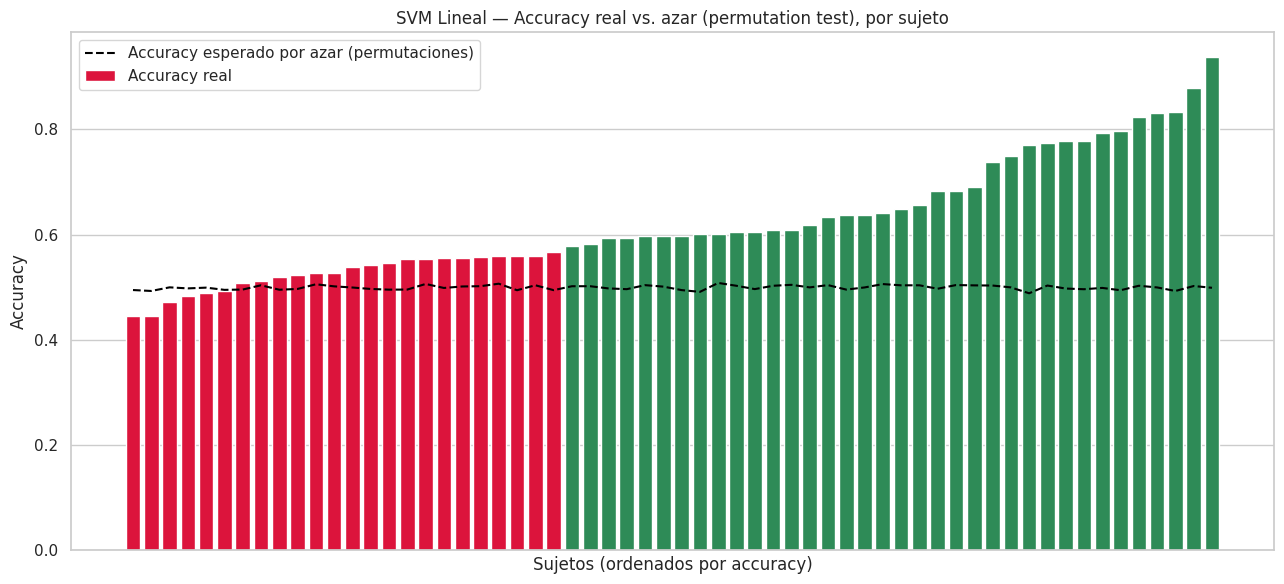

Sujetos con p<0.05 (verde): 36
Sujetos sin significancia (rojo): 24


In [17]:
import matplotlib.pyplot as plt

df_plot = df_pvalue_svm.sort_values('Accuracy_real').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))

colores_barra = df_plot['Significativo_(p<0.05)'].map({True: '#2E8B57', False: '#DC143C'})
ax.bar(range(len(df_plot)), df_plot['Accuracy_real'], color=colores_barra, width=0.8, label='Accuracy real')

ax.plot(range(len(df_plot)), df_plot['Accuracy_permutaciones_mean'],
        color='black', linestyle='--', linewidth=1.5, label='Accuracy esperado por azar (permutaciones)')

ax.set_xlabel('Sujetos (ordenados por accuracy)')
ax.set_ylabel('Accuracy')
ax.set_title('SVM Lineal — Accuracy real vs. azar (permutation test), por sujeto')
ax.set_xticks([])
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Sujetos con p<0.05 (verde): {df_plot['Significativo_(p<0.05)'].sum()}")
print(f"Sujetos sin significancia (rojo): {(~df_plot['Significativo_(p<0.05)']).sum()}")

1. Lectura del gráfico

Confirma numéricamente el 60% (36 verde / 24 rojo), y visualmente muestra algo importante: la transición no es un salto abrupto en un punto claro de accuracy. Hay sujetos rojos (no significativos) con accuracy 0.55-0.58 mezclados muy cerca de sujetos verdes (significativos) con accuracy similar (~0.58-0.60). Esto confirma lo que anticipábamos: el corte de significancia no coincide con un umbral fijo de accuracy, porque el p-value depende también de la variabilidad de la distribución de permutaciones de cada sujeto en particular, no solo del valor de accuracy en sí.

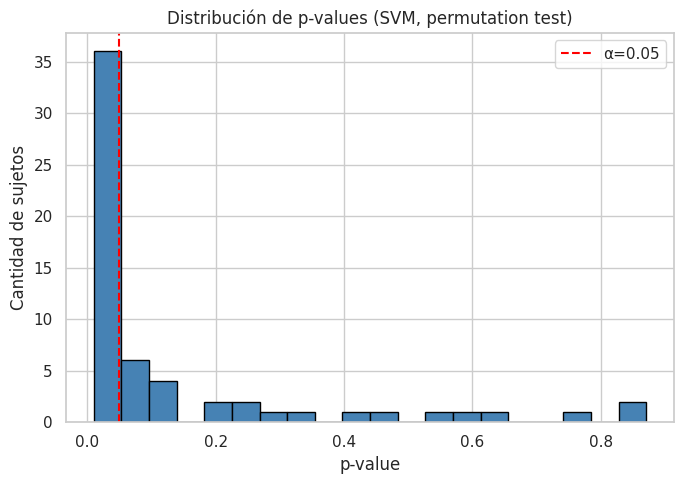

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_pvalue_svm['p_value_vs_chance'], bins=20, color='#4682B4', edgecolor='black')
ax.axvline(x=0.05, color='red', linestyle='--', label='α=0.05')
ax.set_xlabel('p-value')
ax.set_ylabel('Cantidad de sujetos')
ax.set_title('Distribución de p-values (SVM, permutation test)')
ax.legend()
plt.tight_layout()
plt.show()

2. Lectura

El histograma de p-values revela una distribución marcadamente bimodal: la gran mayoría de los sujetos significativos (36) se concentran en p-values muy bajos (≈0.01), evidenciando una separación clara y robusta respecto al azar, no un resultado al filo del umbral convencional de 0.05. Los sujetos sin significancia estadística, por su parte, se distribuyen de forma dispersa entre p=0.1 y p≈0.87, sin concentrarse cerca del punto de corte. Este patrón bimodal sugiere que, en este dataset, la distinción entre sujetos que modulan su señal motora de forma detectable y aquellos que no lo hacen es relativamente nítida.

### Checkpoint


In [ ]:
import os

RUTA_RESULTADOS = os.path.join(PATH_REPO, "resultados")
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# 1. Checkpoint del detalle por sujeto y modelo (CV_Accuracy, CV_Accuracy_std, CV_F1, Train_Accuracy, Gap_overfitting)
ruta_comparacion_cv = os.path.join(RUTA_RESULTADOS, "checkpoint_comparacion_cv.csv")
df_comparacion_cv.to_csv(ruta_comparacion_cv, index=False)
print(f"Checkpoint detalle por sujeto/modelo guardado en: {ruta_comparacion_cv}")

# 2. Checkpoint de la tabla resumen (promedio de cada metrica por modelo, CV)
ruta_tabla_resultados = os.path.join(RUTA_RESULTADOS, "checkpoint_tabla_resultados.csv")
tabla_resultados.to_csv(ruta_tabla_resultados)
print(f"Checkpoint tabla resumen CV (CV_Accuracy, CV_Accuracy_std, CV_F1, Train_Accuracy, Gap_overfitting) guardado en: {ruta_tabla_resultados}")

# 3. Checkpoint de la prueba de significancia (permutation test SVM vs chance level)
ruta_pvalue_svm = os.path.join(RUTA_RESULTADOS, "checkpoint_pvalue_svm.csv")
df_pvalue_svm.to_csv(ruta_pvalue_svm, index=False)
print(f"Checkpoint prueba de significancia (p_value_vs_chance) guardado en: {ruta_pvalue_svm}")

# 4. Checkpoint de las métricas obligatorias completas (Accuracy, Precision, Recall, F1, AUC-ROC, matriz de confusión)
#    -- calculadas retroactivamente sobre los 5 modelos de ML con held-out test
ruta_metricas_completas = os.path.join(RUTA_RESULTADOS, "checkpoint_metricas_completas_ML.csv")
df_metricas_completas.to_csv(ruta_metricas_completas, index=False)
print(f"Checkpoint métricas completas ML (accuracy, precision, recall, f1, auc_roc, TN/FP/FN/TP) guardado en: {ruta_metricas_completas}")

# 5. Checkpoint del resumen agregado de métricas completas por modelo
resumen_metricas_completas = df_metricas_completas.groupby('modelo')[
    ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
].mean().round(4)
ruta_resumen_metricas = os.path.join(RUTA_RESULTADOS, "checkpoint_resumen_metricas_completas.csv")
resumen_metricas_completas.to_csv(ruta_resumen_metricas)
print(f"Checkpoint resumen métricas completas por modelo guardado en: {ruta_resumen_metricas}")

print("\n=== Resumen de métricas CV por modelo ===")
display(tabla_resultados)

print("\n=== Resumen de métricas completas (test held-out) por modelo ===")
display(resumen_metricas_completas)

col_significativo = "Significativo_(p<0.05)"
n_significativos = df_pvalue_svm[col_significativo].sum()
print(f"\nSujetos con señal significativa (p<0.05, SVM): {n_significativos} / {len(df_pvalue_svm)} "
      f"({n_significativos/len(df_pvalue_svm)*100:.1f}%)")

### 🏛️ Modelo: Common Spatial Patterns + Linear Discriminant Analysis (CSP + LDA)

Qué es?
  
  - CSP (Common Spatial Patterns) es un filtrado espacial supervisado que calcula combinaciones lineales de los canales (C3, Cz, C4) maximizando la varianza de la señal para una clase mientras la minimiza para la otra. Explota el fenómeno ERD/ERS: la imaginación motora cambia la amplitud/varianza de la señal en banda mu/beta de forma asimétrica entre C3 y C4 según la mano imaginada.

Hiperparámetros usados:

- n_components (2, 4): cantidad de filtros espaciales retenidos
- component_order (mutual_info, alternate): criterio de selección/orden de los componentes


Por qué trabaja sobre la señal cruda y no sobre las features tabulares?
- CSP necesita la covarianza espacio-temporal completa de la señal (cómo covarían los canales muestra a muestra) para resolver su problema de autovalores. Las features tabulares (Skewness, AR, potencia, etc.) ya son resúmenes escalares por trial, sin esa estructura temporal — no sirven como insumo para CSP. Además, CSP no es un clasificador que reciba features ya calculadas: es en sí mismo un método de extracción de características, alternativo al pipeline manual de Fases 1-2. Por eso, en CSP+LDA, CSP cumple el rol de extracción/selección y LDA el de clasificador final.

##### - Configuración de entorno

In [ ]:
import os
import sys

try:
    from google.colab import drive
    print("-> Entorno detectado: Google Colab.")

     # INSTALACIÓN DE MNE (Ya que no viene por defecto en Colab)
    print("-> Instalando librería MNE neuroscience...")
    !pip install mne -q

    drive.mount('/content/drive')

    PATH_DRIVE = '/content/drive/MyDrive'
    REPO_NAME = 'BCI-MENTORIA-UNC'
    PATH_REPO = os.path.join(PATH_DRIVE, REPO_NAME)

    os.chdir(PATH_REPO)
    sys.path.append(PATH_REPO)
    print(f"-> Directorio de trabajo configurado en: {os.getcwd()}")

except ImportError:
    print("-> Entorno detectado: Local PC.")




In [ ]:
!pip install mne -q

##### ENTRENAMIENTO (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)



In [ ]:
import os
import json
import time
import pickle
import numpy as np
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset


mne.set_log_level('ERROR')

def binarize_y(y):
    unique_classes = np.unique(y)
    assert len(unique_classes) == 2, "y debe tener exactamente dos clases distintas"
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    y_bin = np.vectorize(class_to_bin.get)(y)
    return y_bin, bin_to_class

DB_SELECCIONADA = "Dreyer2023A"
CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128

lista_sujetos = list(df_features_wide['subject_id'].unique())

dataset = PreprocessedDataset(
    db_name=DB_SELECCIONADA,
    sessions=SESSIONS,
    subjects=lista_sujetos,
    data_to_load=DATA_TO_LOAD,
    channels=CHANNELS,
)
print(f"Dataset instanciado. Sujetos: {len(lista_sujetos)}")

RANDOM_SEED = 45
SPLIT_TEST_SIZE = 0.20
K_FOLDS = 5
SCORING = "accuracy"

# ============================================================
# Identificador de esta versión del experimento
# ============================================================
VERSION_EXPERIMENTO = "sin_banda_sin_reg"

MODEL_NAME = "CSP_LDA"
DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME)
os.makedirs(DIR_BASE_MODELO, exist_ok=True)

ruta_checkpoint = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME}_{VERSION_EXPERIMENTO}.csv")
# ============================================================

if os.path.exists(ruta_checkpoint):
    df_global_csp = pd.read_csv(ruta_checkpoint)
    sujetos_ya_procesados = set(df_global_csp['subject_id'].tolist())
    print(f"Checkpoint encontrado ({VERSION_EXPERIMENTO}): {len(sujetos_ya_procesados)} sujetos ya procesados")
else:
    df_global_csp = pd.DataFrame()
    sujetos_ya_procesados = set()

sujetos_pendientes = [s for s in lista_sujetos if s not in sujetos_ya_procesados]
print(f"Sujetos pendientes: {len(sujetos_pendientes)}")

grid_parametros = {
    "csp__n_components": [2, 4],
    "csp__component_order": ["mutual_info", "alternate"]
}

inicio = time.time()

for sujeto_id in sujetos_pendientes:
    t0 = time.time()
    try:
        X_eeg_raw, y_labels_raw, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_raw, _ = binarize_y(y_labels_raw)

        X_train, X_test, y_train, y_test = train_test_split(
            X_eeg_raw, y_labels_raw, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_raw, random_state=RANDOM_SEED
        )

        pipe = Pipeline([
            ("csp", CSP()),
            ("clf", LinearDiscriminantAnalysis())
        ])

        cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
        grid_search = GridSearchCV(pipe, param_grid=grid_parametros, cv=cv_estrategia,
                                     scoring=SCORING, n_jobs=-1)
        grid_search.fit(X_train, y_train)

        mejor_modelo = grid_search.best_estimator_
        y_pred = mejor_modelo.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)

        dir_sujeto = os.path.join(DIR_BASE_MODELO, VERSION_EXPERIMENTO, f"subject_{sujeto_id}")
        os.makedirs(dir_sujeto, exist_ok=True)

        with open(os.path.join(dir_sujeto, "mejor_modelo.pkl"), 'wb') as f:
            pickle.dump(mejor_modelo, f)

        with open(os.path.join(dir_sujeto, "metricas_hiperparametros.json"), 'w') as f:
            json.dump({
                "mejor_hiperparametros": grid_search.best_params_,
                "metricas_cv_accuracy": grid_search.best_score_,
                "metricas_test": {"accuracy": test_acc}
            }, f, indent=4)

        fila = {
            "subject_id": sujeto_id,
            "Modelo": MODEL_NAME,
            "Version": VERSION_EXPERIMENTO,
            "Best_Params": str(grid_search.best_params_),
            "CV_Accuracy": grid_search.best_score_,
            "Test_Accuracy": test_acc
        }
        df_global_csp = pd.concat([df_global_csp, pd.DataFrame([fila])], ignore_index=True)
        df_global_csp.to_csv(ruta_checkpoint, index=False)

        print(f"Sujeto {sujeto_id}: Test_Acc={test_acc:.4f} ({time.time()-t0:.1f}s) "
              f"[{len(df_global_csp)}/{len(lista_sujetos)}]")

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

print(f"\n⭐ Tiempo total: {(time.time()-inicio)/60:.1f} min")
print(f"Archivo consolidado en: {ruta_checkpoint}")
display(df_global_csp)

In [ ]:
import ast

# 1. Determinar la configuración más frecuente entre los 60 GridSearchCV (versión sin_banda_sin_reg)
config_mas_frecuente = df_global_csp['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos ({VERSION_EXPERIMENTO}):\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones encontradas:")
display(df_global_csp['Best_Params'].value_counts())

# Convertir el string de vuelta a diccionario para poder usarlo
mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

N_COMPONENTS_FINAL = mejores_params_finales['csp__n_components']
COMPONENT_ORDER_FINAL = mejores_params_finales['csp__component_order']

##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, accuracy_score
)
from sklearn.model_selection import cross_validate

metricas_finales_csp = []
resultados_csp_metricas = []  # <-- para las métricas completas (Precision/Recall/AUC-ROC/matriz)

for sujeto_id in lista_sujetos:
    print(f"\n🚀 Reentrenando {MODEL_NAME} ({VERSION_EXPERIMENTO}) para Sujeto: {sujeto_id}")

    try:
        X_eeg_raw, y_labels_raw, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_raw, _ = binarize_y(y_labels_raw)

        X_train, X_test, y_train, y_test = train_test_split(
            X_eeg_raw, y_labels_raw, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_raw, random_state=RANDOM_SEED
        )

        modelo_final = Pipeline([
            ("csp", CSP(n_components=N_COMPONENTS_FINAL, component_order=COMPONENT_ORDER_FINAL)),
            ("clf", LinearDiscriminantAnalysis())
        ])

        cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
        scores_cv = cross_validate(
            modelo_final, X_train, y_train, cv=cv_estrategia,
            scoring=['accuracy', 'f1'], return_train_score=True, n_jobs=-1
        )

        modelo_final.fit(X_train, y_train)
        y_pred_final = modelo_final.predict(X_test)
        test_acc_final = accuracy_score(y_test, y_pred_final)
        test_f1_final = f1_score(y_test, y_pred_final)

        metricas_finales_csp.append({
            "subject_id": sujeto_id,
            "Modelo": MODEL_NAME,
            "Version": VERSION_EXPERIMENTO,
            "N_components_final": N_COMPONENTS_FINAL,
            "Component_order_final": COMPONENT_ORDER_FINAL,
            "CV_Accuracy": scores_cv['test_accuracy'].mean(),
            "CV_Accuracy_std": scores_cv['test_accuracy'].std(),
            "CV_F1": scores_cv['test_f1'].mean(),
            "Train_Accuracy": scores_cv['train_accuracy'].mean(),
            "Gap_overfitting": scores_cv['train_accuracy'].mean() - scores_cv['test_accuracy'].mean(),
            "Test_Accuracy_Final": test_acc_final,
            "Test_F1_Final": test_f1_final
        })

        # --- NUEVO: métricas completas obligatorias (Precision, Recall, AUC-ROC, matriz de confusión) ---
        try:
            if hasattr(modelo_final, 'decision_function'):
                y_score = modelo_final.decision_function(X_test)
            else:
                y_score = modelo_final.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_score)
        except Exception:
            auc = np.nan

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final, labels=[0, 1]).ravel()

        resultados_csp_metricas.append({
            'subject_id': sujeto_id,
            'modelo': 'CSP_LDA',
            'accuracy': test_acc_final,
            'precision': precision_score(y_test, y_pred_final, zero_division=0),
            'recall': recall_score(y_test, y_pred_final, zero_division=0),
            'f1': test_f1_final,
            'auc_roc': auc,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

        dir_sujeto = os.path.join(DIR_BASE_MODELO, VERSION_EXPERIMENTO, f"subject_{sujeto_id}")
        os.makedirs(dir_sujeto, exist_ok=True)
        with open(os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl"), 'wb') as f:
            pickle.dump(modelo_final, f)

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

df_final_csp = pd.DataFrame(metricas_finales_csp)
ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME}_{VERSION_EXPERIMENTO}.csv")
df_final_csp.to_csv(ruta_csv_final, index=False)

# --- NUEVO: agregar las métricas completas de CSP_LDA a df_metricas_completas ---
df_csp_metricas = pd.DataFrame(resultados_csp_metricas)
df_metricas_completas = pd.concat([df_metricas_completas, df_csp_metricas], ignore_index=True)

ruta_metricas = os.path.join(PATH_REPO, "models", "comparaciones", "metricas_completas_ML.csv")
df_metricas_completas.to_csv(ruta_metricas, index=False)

print(f"\nTest_Accuracy_Final promedio ({VERSION_EXPERIMENTO}): "
      f"{df_final_csp['Test_Accuracy_Final'].mean():.4f} ± {df_final_csp['Test_Accuracy_Final'].std():.4f}")
display(df_final_csp)

print(f"\ndf_metricas_completas actualizado:")
print(df_metricas_completas.groupby('modelo').size())

In [ ]:
import pandas as pd
import os

df_final_svm = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv"))
df_final_csp = pd.read_csv(os.path.join(PATH_REPO, "models", "CSP_LDA", "df_final_CSP_LDA_sin_banda_sin_reg.csv"))

print(f"df_final_svm: {len(df_final_svm)} filas")
print(f"df_final_csp: {len(df_final_csp)} filas, versión: {df_final_csp['Version'].iloc[0]}")

#### Comparación de métricas

In [22]:
#Primero va esto
import time

DIR_COMPARACIONES = os.path.join(PATH_REPO, "models", "comparaciones")
os.makedirs(DIR_COMPARACIONES, exist_ok=True)
ruta_checkpoint_sin_ajustes = os.path.join(DIR_COMPARACIONES, "metricas_csp_sin_ajustes_checkpoint.csv")

if os.path.exists(ruta_checkpoint_sin_ajustes):
    df_csp_sin_ajustes_test = pd.read_csv(ruta_checkpoint_sin_ajustes)
    sujetos_ya_procesados = set(df_csp_sin_ajustes_test['subject_id'].tolist())
    print(f"Checkpoint encontrado: {len(sujetos_ya_procesados)} sujetos ya procesados")
else:
    df_csp_sin_ajustes_test = pd.DataFrame()
    sujetos_ya_procesados = set()

sujetos_pendientes = [s for s in lista_sujetos_dreyer if s not in sujetos_ya_procesados]
print(f"Sujetos pendientes: {len(sujetos_pendientes)}")

inicio = time.time()

for sujeto_id in sujetos_pendientes:
    t0 = time.time()
    try:
        X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)

        X_train, X_test, y_train, y_test = train_test_split(
            X_eeg_raw, y_labels_bin, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_bin, random_state=RANDOM_SEED
        )

        modelo = cargar_modelo('CSP_LDA', 'sin_banda_sin_reg', sujeto_id)
        metricas = calcular_metricas_completas(modelo, X_test, y_test)
        metricas['modelo'] = 'CSP_LDA_sin_ajustes'
        metricas['subject_id'] = sujeto_id

        df_csp_sin_ajustes_test = pd.concat([df_csp_sin_ajustes_test, pd.DataFrame([metricas])], ignore_index=True)
        df_csp_sin_ajustes_test.to_csv(ruta_checkpoint_sin_ajustes, index=False)

        print(f"Sujeto {sujeto_id}: OK ({time.time()-t0:.1f}s) [{len(df_csp_sin_ajustes_test)}/{len(lista_sujetos_dreyer)}]")

    except Exception as e:
        print(f" ❌ Sujeto {sujeto_id}: {e}")
        continue

print(f"\n⭐ Tiempo total: {(time.time()-inicio)/60:.1f} min")

Sujetos pendientes: 60
Sujeto 1: OK (0.2s) [1/60]
Sujeto 2: OK (0.1s) [2/60]
Sujeto 3: OK (0.1s) [3/60]
Sujeto 4: OK (0.1s) [4/60]
Sujeto 5: OK (0.2s) [5/60]
Sujeto 6: OK (0.1s) [6/60]
Sujeto 7: OK (0.1s) [7/60]
Sujeto 8: OK (0.2s) [8/60]
Sujeto 9: OK (0.1s) [9/60]
Sujeto 10: OK (0.2s) [10/60]
Sujeto 11: OK (0.1s) [11/60]
Sujeto 12: OK (0.1s) [12/60]
Sujeto 13: OK (0.1s) [13/60]
Sujeto 14: OK (0.1s) [14/60]
Sujeto 15: OK (0.1s) [15/60]
Sujeto 16: OK (0.1s) [16/60]
Sujeto 17: OK (0.1s) [17/60]
Sujeto 18: OK (0.1s) [18/60]
Sujeto 19: OK (0.2s) [19/60]
Sujeto 20: OK (0.3s) [20/60]
Sujeto 21: OK (0.2s) [21/60]
Sujeto 22: OK (0.2s) [22/60]
Sujeto 23: OK (0.1s) [23/60]
Sujeto 24: OK (0.2s) [24/60]
Sujeto 25: OK (0.3s) [25/60]
Sujeto 26: OK (0.2s) [26/60]
Sujeto 27: OK (0.3s) [27/60]
Sujeto 28: OK (0.2s) [28/60]
Sujeto 29: OK (0.4s) [29/60]
Sujeto 30: OK (0.4s) [30/60]
Sujeto 31: OK (0.3s) [31/60]
Sujeto 32: OK (0.4s) [32/60]
Sujeto 33: OK (0.5s) [33/60]
Sujeto 34: OK (0.5s) [34/60]
Sujeto 35

In [23]:
#Primero va esto
from scipy.stats import wilcoxon
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Cargar la versión CSP SIN banda ni regularización
# ============================================================
df_final_csp_sin_ajustes = pd.read_csv(
    os.path.join(PATH_REPO, "models", "CSP_LDA", "df_final_CSP_LDA_sin_banda_sin_reg.csv")
)
assert df_final_csp_sin_ajustes['Version'].iloc[0] == "sin_banda_sin_reg"

# Recalcular métricas completas de test (Accuracy/Precision/Recall/F1/AUC-ROC/matriz)
# usando el modelo SIN banda ni reg, y la señal SIN filtrar
resultados_csp_sin_ajustes = []
for sujeto_id in lista_sujetos_dreyer:
    try:
        X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)

        # SIN filtrado de banda (coherente con esta versión del experimento)
        X_train, X_test, y_train, y_test = train_test_split(
            X_eeg_raw, y_labels_bin, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_bin, random_state=RANDOM_SEED
        )

        modelo = cargar_modelo('CSP_LDA', 'sin_banda_sin_reg', sujeto_id)
        metricas = calcular_metricas_completas(modelo, X_test, y_test)
        metricas['modelo'] = 'CSP_LDA_sin_ajustes'
        metricas['subject_id'] = sujeto_id
        resultados_csp_sin_ajustes.append(metricas)
    except Exception as e:
        print(f" ❌ Sujeto {sujeto_id}: {e}")
        continue

df_csp_sin_ajustes_test = pd.DataFrame(resultados_csp_sin_ajustes)

columnas_comparar_cv = ['CV_Accuracy', 'CV_Accuracy_std', 'CV_F1', 'Train_Accuracy', 'Gap_overfitting']
columnas_comparar_test = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'TN', 'FP', 'FN', 'TP']

# --- 1. Comparación de métricas de CV ---
df_comparacion_svm_csp_cv = df_final_svm[['subject_id'] + columnas_comparar_cv].rename(
    columns={c: f'SVM_{c}' for c in columnas_comparar_cv}
).merge(
    df_final_csp_sin_ajustes[['subject_id'] + columnas_comparar_cv].rename(
        columns={c: f'CSP_{c}' for c in columnas_comparar_cv}
    ),
    on='subject_id', how='inner'
)

# --- 2. Comparación de métricas completas (test held-out) ---
df_svm_test = df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][
    ['subject_id'] + columnas_comparar_test
].rename(columns={c: f'SVM_{c}' for c in columnas_comparar_test})

df_csp_test = df_csp_sin_ajustes_test[['subject_id'] + columnas_comparar_test].rename(
    columns={c: f'CSP_{c}' for c in columnas_comparar_test}
)

df_comparacion_svm_csp_test = df_svm_test.merge(df_csp_test, on='subject_id', how='inner')

# --- 3. Resumen promedio de ambos modelos, lado a lado ---
resumen_cv = pd.DataFrame({
    'SVM': df_final_svm[columnas_comparar_cv].mean(),
    'CSP+LDA (sin ajustes)': df_final_csp_sin_ajustes[columnas_comparar_cv].mean()
}).round(4)
print("=== Resumen comparativo — métricas de CV (promedio 60 sujetos) ===")
display(resumen_cv)

resumen_test = pd.DataFrame({
    'SVM': df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][columnas_comparar_test].mean(),
    'CSP+LDA (sin ajustes)': df_csp_sin_ajustes_test[columnas_comparar_test].mean()
}).round(4)
print("\n=== Resumen comparativo — métricas completas de test (promedio 60 sujetos) ===")
display(resumen_test)

# --- 4. Test de Wilcoxon pareado ---
print("\n=== Wilcoxon pareado (SVM vs CSP+LDA sin ajustes) — métricas de test ===")
resultados_wilcoxon = []
metricas_para_wilcoxon = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']

for metrica in metricas_para_wilcoxon:
    stat, p_value = wilcoxon(
        df_comparacion_svm_csp_test[f'SVM_{metrica}'],
        df_comparacion_svm_csp_test[f'CSP_{metrica}']
    )
    resultados_wilcoxon.append({'Métrica': metrica, 'p_value': round(p_value, 4)})
    print(f"{metrica}: p-value={p_value:.4f}")

df_wilcoxon_resumen = pd.DataFrame(resultados_wilcoxon)

# --- 5. Guardar todo (nombres distintos, para no pisar la comparación con banda+reg) ---
DIR_COMPARACIONES = os.path.join(PATH_REPO, "models", "comparaciones")
os.makedirs(DIR_COMPARACIONES, exist_ok=True)

df_comparacion_svm_csp_cv.to_csv(os.path.join(DIR_COMPARACIONES, "comparativa_SVM_vs_CSP_sin_ajustes_CV.csv"), index=False)
df_comparacion_svm_csp_test.to_csv(os.path.join(DIR_COMPARACIONES, "comparativa_SVM_vs_CSP_sin_ajustes_metricas_completas.csv"), index=False)
df_wilcoxon_resumen.to_csv(os.path.join(DIR_COMPARACIONES, "wilcoxon_SVM_vs_CSP_sin_ajustes.csv"), index=False)

print(f"\n💾 Guardado en: {DIR_COMPARACIONES}")

=== Resumen comparativo — métricas de CV (promedio 60 sujetos) ===


,SVM,CSP+LDA (sin ajustes)
CV_Accuracy,0.6229,0.5392
CV_Accuracy_std,0.0538,0.0516
CV_F1,0.6158,0.5270
Train_Accuracy,0.6783,0.5755
Gap_overfitting,0.0553,0.0363



=== Resumen comparativo — métricas completas de test (promedio 60 sujetos) ===


,SVM,CSP+LDA (sin ajustes)
accuracy,0.6229,0.5431
precision,0.6288,0.5435
recall,0.6174,0.5540
f1,0.6164,0.5446
auc_roc,0.6652,0.5578
TN,19.9500,16.8833
FP,11.7667,14.8333
FN,12.1000,14.1667
TP,19.6333,17.5667



=== Wilcoxon pareado (SVM vs CSP+LDA sin ajustes) — métricas de test ===
accuracy: p-value=0.0000
precision: p-value=0.0000
recall: p-value=0.0051
f1: p-value=0.0001
auc_roc: p-value=0.0000

💾 Guardado en: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones


SVM Lineal resultó significativamente superior a CSP+LDA en Accuracy, Precision, F1 y, con el nivel de significancia más fuerte, en AUC-ROC (p=0.0000) — la métrica más relevante para evaluar la capacidad discriminativa independiente del umbral de decisión. El AUC-ROC de SVM (0.6652) fue muy superior al de CSP+LDA (0.5578), lo que confirma que SVM discrimina de manera más consistente entre ambas clases en su conjunto. En cuanto a Recall, aunque SVM mostró un valor ligeramente mayor (0.6174 vs. 0.5540), la diferencia fue menos marcada y con significancia estadística moderada (p=0.0051), lo que indica que ambos modelos logran una sensibilidad comparable para detectar la clase positiva. Este patrón refuerza la elección de SVM Lineal como modelo clásico de referencia, sin invalidar a CSP+LDA como baseline válido, cuyo desempeño se mantiene razonablemente competitivo en métricas donde la diferencia no alcanzó la misma magnitud.

Teniendo en cuenta esto, se podrían introducir mejoras en el modelo CSP con el objetivo de aumentar el accuracy y reducir el gap frente a SVM. Entre ellas, destacan el recorte de bandas trabajando con la banda alfa (8–12 Hz) y la regularización de covarianza (reg='ledoit_wolf' o 'oas'). Esta última suele ser necesaria porque, con pocos trials por sujeto, la matriz de covarianza cruda es inestable y afecta la robustez del clasificador.

## Agregar filtrado de banda + regularización (grilla y reentrenamiento final)

##### ENTRENAMIENTO (CON BÚSQUEDA EN GRILLA Y VALIDACIÓN CRUZADA)

In [ ]:
import os
import numpy as np
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import time
import pickle
import json

mne.set_log_level('ERROR')

# ============================================================
# Nueva versión del experimento: banda como hiperparámetro + reg sin None
# ============================================================
VERSION_EXPERIMENTO = "con_banda_y_reg"

DIR_BASE_MODELO = os.path.join(PATH_REPO, "models", MODEL_NAME)
ruta_checkpoint = os.path.join(DIR_BASE_MODELO, f"df_global_{MODEL_NAME}_{VERSION_EXPERIMENTO}.csv")

if os.path.exists(ruta_checkpoint):
    os.remove(ruta_checkpoint)

df_global_csp = pd.DataFrame()
sujetos_pendientes = lista_sujetos

# --- Bandas a comparar (esto NO es un parámetro de GridSearchCV: filtra la señal ANTES
#     del split, por eso se recorre manualmente en un loop externo por sujeto) ---
BANDAS = {
    "alfa": (8, 12),
    "beta": (13, 30),
    "alfabeta": (8, 30)
}

grid_parametros = {
    "csp__n_components": [2, 4],
    "csp__component_order": ["mutual_info", "alternate"],
    "csp__reg": ["ledoit_wolf", "oas"]   # <-- sin None
}

inicio = time.time()

for sujeto_id in sujetos_pendientes:
    t0 = time.time()
    print(f"\n🚀 Entrenando {MODEL_NAME} para Sujeto: {sujeto_id}")

    try:
        X_eeg_raw, y_labels_raw, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_raw, _ = binarize_y(y_labels_raw)

        # --- Probar las 3 bandas y quedarse con la de mejor CV_Accuracy para este sujeto ---
        mejor_resultado_sujeto = None

        for nombre_banda, (l_freq, h_freq) in BANDAS.items():
            X_eeg_filtrado = mne.filter.filter_data(
                X_eeg_raw.astype(np.float64), sfreq=SFREQ,
                l_freq=l_freq, h_freq=h_freq, method='iir', verbose=False
            )

            # Mismo random_state -> misma partición de trials entre bandas (comparación justa)
            X_train, X_test, y_train, y_test = train_test_split(
                X_eeg_filtrado, y_labels_raw, test_size=SPLIT_TEST_SIZE,
                stratify=y_labels_raw, random_state=RANDOM_SEED
            )

            pipe = Pipeline([
                ("csp", CSP()),
                ("clf", LinearDiscriminantAnalysis())
            ])

            cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
            grid_search = GridSearchCV(pipe, param_grid=grid_parametros, cv=cv_estrategia,
                                         scoring=SCORING, n_jobs=-1)
            grid_search.fit(X_train, y_train)

            resultado_banda = {
                "banda": nombre_banda,
                "l_freq": l_freq,
                "h_freq": h_freq,
                "grid_search": grid_search,
                "X_test": X_test,
                "y_test": y_test,
                "CV_Accuracy": grid_search.best_score_
            }

            # Guardarse el mejor entre las 3 bandas, comparando por CV_Accuracy
            if mejor_resultado_sujeto is None or resultado_banda["CV_Accuracy"] > mejor_resultado_sujeto["CV_Accuracy"]:
                mejor_resultado_sujeto = resultado_banda

        # --- Evaluación final en test, con la banda+config ganadora ---
        grid_search_final = mejor_resultado_sujeto["grid_search"]
        mejor_modelo = grid_search_final.best_estimator_
        y_pred = mejor_modelo.predict(mejor_resultado_sujeto["X_test"])
        test_acc = accuracy_score(mejor_resultado_sujeto["y_test"], y_pred)

        best_params_con_banda = dict(grid_search_final.best_params_)
        best_params_con_banda["banda"] = mejor_resultado_sujeto["banda"]

        print(f" -> Mejor banda: {mejor_resultado_sujeto['banda']} "
              f"({mejor_resultado_sujeto['l_freq']}-{mejor_resultado_sujeto['h_freq']}Hz)")
        print(f" -> Mejor configuración CV: {best_params_con_banda}")
        print(f" -> [TEST] Accuracy: {test_acc:.4f} ({time.time()-t0:.1f}s)")

        dir_sujeto = os.path.join(DIR_BASE_MODELO, VERSION_EXPERIMENTO, f"subject_{sujeto_id}")
        os.makedirs(dir_sujeto, exist_ok=True)

        with open(os.path.join(dir_sujeto, "mejor_modelo.pkl"), 'wb') as f:
            pickle.dump(mejor_modelo, f)

        with open(os.path.join(dir_sujeto, "metricas_hiperparametros.json"), 'w') as f:
            json.dump({
                "mejor_hiperparametros": best_params_con_banda,
                "metricas_cv_accuracy": mejor_resultado_sujeto["CV_Accuracy"],
                "metricas_test": {"accuracy": test_acc}
            }, f, indent=4)

        fila = {
            "subject_id": sujeto_id,
            "Modelo": MODEL_NAME,
            "Version": VERSION_EXPERIMENTO,
            "Banda": mejor_resultado_sujeto["banda"],
            "Best_Params": str(best_params_con_banda),
            "CV_Accuracy": mejor_resultado_sujeto["CV_Accuracy"],
            "Test_Accuracy": test_acc
        }
        df_global_csp = pd.concat([df_global_csp, pd.DataFrame([fila])], ignore_index=True)
        df_global_csp.to_csv(ruta_checkpoint, index=False)

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

print(f"\n⭐ Tiempo total: {(time.time()-inicio)/60:.1f} min")
print(f"Filas finales en df_global_csp: {len(df_global_csp)}")
display(df_global_csp)

##### Observación de hiperparámetros

In [ ]:
import ast

# 1. Determinar la configuración más frecuente entre los 60 sujetos (incluye banda ahora)
config_mas_frecuente = df_global_csp['Best_Params'].mode()[0]
print(f"Configuración de hiperparámetros más frecuente entre sujetos ({VERSION_EXPERIMENTO}):\n{config_mas_frecuente}")
print(f"\nDistribución de configuraciones COMPLETAS encontradas:")
display(df_global_csp['Best_Params'].value_counts())

mejores_params_finales = ast.literal_eval(config_mas_frecuente)
print(f"\nHiperparámetros finales a usar: {mejores_params_finales}")

N_COMPONENTS_FINAL = mejores_params_finales['csp__n_components']
COMPONENT_ORDER_FINAL = mejores_params_finales['csp__component_order']
REG_FINAL = mejores_params_finales['csp__reg']
BANDA_FINAL = mejores_params_finales['banda']

L_FREQ_FINAL, H_FREQ_FINAL = BANDAS[BANDA_FINAL]

print(f"\n--- Resumen ---")
print(f"n_components = {N_COMPONENTS_FINAL}")
print(f"component_order = {COMPONENT_ORDER_FINAL}")
print(f"reg = {REG_FINAL}")
print(f"banda = {BANDA_FINAL} ({L_FREQ_FINAL}-{H_FREQ_FINAL} Hz)")

# 2. Distribuciones marginales (útil para el informe, ya que con 60 sujetos y muchas
#    combinaciones posibles, el consenso exacto puede estar fragmentado)
print(f"\n--- Distribución marginal por hiperparámetro (más robusto que la combinación exacta) ---")
print("\nBanda:")
display(df_global_csp['Banda'].value_counts())

print("\nreg (extraído de Best_Params):")
df_global_csp['reg_extraido'] = df_global_csp['Best_Params'].apply(lambda x: ast.literal_eval(x)['csp__reg'])
display(df_global_csp['reg_extraido'].value_counts())

print("\nn_components (extraído de Best_Params):")
df_global_csp['n_components_extraido'] = df_global_csp['Best_Params'].apply(lambda x: ast.literal_eval(x)['csp__n_components'])
display(df_global_csp['n_components_extraido'].value_counts())

print("\ncomponent_order (extraído de Best_Params):")
df_global_csp['component_order_extraido'] = df_global_csp['Best_Params'].apply(lambda x: ast.literal_eval(x)['csp__component_order'])
display(df_global_csp['component_order_extraido'].value_counts())

### Consideraciones:
A nivel marginal _alfa_ y _alfabeta_ están empatadas, pero al considerar la combinación completa de hiperparámetros, _alfabeta+ledoit_wolf+4 componentes_ fue la configuración conjunta más robusta. Esto es interesante porque muestra que la elección de banda óptima no es independiente de los demás hiperparámetros.

##### HIPERPARÁMETROS FINALES (CONSENSO ENTRE SUJETOS) Y REENTRENAMIENTO DESDE CERO

In [ ]:
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_validate

metricas_finales_csp = []

for sujeto_id in lista_sujetos:
    print(f"\n🚀 Reentrenando {MODEL_NAME} ({VERSION_EXPERIMENTO}) para Sujeto: {sujeto_id}")

    try:
        X_eeg_raw, y_labels_raw, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_raw, _ = binarize_y(y_labels_raw)

        # Filtrado con la BANDA de consenso (no fija en Alfa, ahora depende de BANDA_FINAL)
        X_eeg_filtrado = mne.filter.filter_data(
            X_eeg_raw.astype(np.float64), sfreq=SFREQ,
            l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False
        )

        X_train, X_test, y_train, y_test = train_test_split(
            X_eeg_filtrado, y_labels_raw, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_raw, random_state=RANDOM_SEED
        )

        modelo_final = Pipeline([
            ("csp", CSP(n_components=N_COMPONENTS_FINAL,
                        component_order=COMPONENT_ORDER_FINAL,
                        reg=REG_FINAL)),
            ("clf", LinearDiscriminantAnalysis())
        ])

        cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
        scores_cv = cross_validate(
            modelo_final, X_train, y_train, cv=cv_estrategia,
            scoring=['accuracy', 'f1'], return_train_score=True, n_jobs=-1
        )

        modelo_final.fit(X_train, y_train)
        y_pred_final = modelo_final.predict(X_test)
        test_acc_final = accuracy_score(y_test, y_pred_final)
        test_f1_final = f1_score(y_test, y_pred_final)

        metricas_finales_csp.append({
            "subject_id": sujeto_id,
            "Modelo": MODEL_NAME,
            "Version": VERSION_EXPERIMENTO,   # <-- ESTA columna es la que chequea el assert
            "N_components_final": N_COMPONENTS_FINAL,
            "Component_order_final": COMPONENT_ORDER_FINAL,
            "Reg_final": REG_FINAL,
            "Banda_final": BANDA_FINAL,
            "CV_Accuracy": scores_cv['test_accuracy'].mean(),
            "CV_Accuracy_std": scores_cv['test_accuracy'].std(),
            "CV_F1": scores_cv['test_f1'].mean(),
            "Train_Accuracy": scores_cv['train_accuracy'].mean(),
            "Gap_overfitting": scores_cv['train_accuracy'].mean() - scores_cv['test_accuracy'].mean(),
            "Test_Accuracy_Final": test_acc_final,
            "Test_F1_Final": test_f1_final
        })

        dir_sujeto = os.path.join(DIR_BASE_MODELO, VERSION_EXPERIMENTO, f"subject_{sujeto_id}")
        os.makedirs(dir_sujeto, exist_ok=True)
        with open(os.path.join(dir_sujeto, "modelo_final_reentrenado.pkl"), 'wb') as f:
            pickle.dump(modelo_final, f)

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

df_final_csp = pd.DataFrame(metricas_finales_csp)
ruta_csv_final = os.path.join(DIR_BASE_MODELO, f"df_final_{MODEL_NAME}_{VERSION_EXPERIMENTO}.csv")
df_final_csp.to_csv(ruta_csv_final, index=False)

print(f"\nTest_Accuracy_Final promedio ({VERSION_EXPERIMENTO}): "
      f"{df_final_csp['Test_Accuracy_Final'].mean():.4f} ± {df_final_csp['Test_Accuracy_Final'].std():.4f}")
display(df_final_csp)

### Tabla comparativa ampliada: SVM Lineal vs CSP+LDA (ahora con el CSP corregido)

In [26]:
resultados_csp_metricas_v2 = []

for sujeto_id in lista_sujetos_dreyer:
    try:
        X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)
        X_filtrado = mne.filter.filter_data(
            X_eeg_raw.astype(np.float64), sfreq=SFREQ,
            l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False
        )
        X_train, X_test, y_train, y_test = train_test_split(
            X_filtrado, y_labels_bin, test_size=SPLIT_TEST_SIZE,
            stratify=y_labels_bin, random_state=RANDOM_SEED
        )
        modelo = cargar_modelo('CSP_LDA', 'con_banda_y_reg', sujeto_id)
        metricas = calcular_metricas_completas(modelo, X_test, y_test)
        metricas['modelo'] = 'CSP_LDA'
        metricas['subject_id'] = sujeto_id
        resultados_csp_metricas_v2.append(metricas)
    except Exception as e:
        print(f" ❌ Sujeto {sujeto_id}: {e}")
        continue

df_csp_metricas_v2 = pd.DataFrame(resultados_csp_metricas_v2)
print("Nuevo resultado CSP_LDA:")
print(df_csp_metricas_v2[['accuracy','precision','recall','f1','auc_roc']].mean().round(4))

df_metricas_completas = df_metricas_completas[df_metricas_completas['modelo'] != 'CSP_LDA']
df_metricas_completas = pd.concat([df_metricas_completas, df_csp_metricas_v2], ignore_index=True)

ruta_metricas = os.path.join(PATH_REPO, "models", "comparaciones", "metricas_completas_ML.csv")
df_metricas_completas.to_csv(ruta_metricas, index=False)

print("\nResumen final por modelo:")
print(df_metricas_completas.groupby('modelo')[['accuracy','auc_roc']].mean().round(4))

Nuevo resultado CSP_LDA:
accuracy     0.6025
precision    0.6009
recall       0.6052
f1           0.5992
auc_roc      0.6323
dtype: float64

Resumen final por modelo:
              accuracy  auc_roc
modelo                         
CSP_LDA         0.6025   0.6323
DecisionTree    0.5722   0.5886
PCA_LDA         0.5976   0.6263
RandomForest    0.6001   0.6394
SVM             0.6229   0.6652


In [27]:
import os
from scipy.stats import wilcoxon

# ============================================================
# Aviso: usar el df_final_csp de la versión corregida (con_banda_y_reg)
# ============================================================
assert df_final_csp['Version'].iloc[0] == "con_banda_y_reg", (
    "df_final_csp no corresponde a la versión con_banda_y_reg. "
    "Volvé a correr el reentrenamiento final con los hiperparámetros de consenso "
    "(N_COMPONENTS_FINAL, COMPONENT_ORDER_FINAL, REG_FINAL, BANDA_FINAL) antes de comparar."
)

columnas_comparar = ['CV_Accuracy', 'CV_Accuracy_std', 'CV_F1', 'Train_Accuracy',
                     'Gap_overfitting', 'Test_Accuracy_Final']

df_comparacion_svm_csp = df_final_svm[['subject_id'] + columnas_comparar].rename(
    columns={c: f'SVM_{c}' for c in columnas_comparar}
).merge(
    df_final_csp[['subject_id'] + columnas_comparar].rename(
        columns={c: f'CSP_{c}' for c in columnas_comparar}
    ),
    on='subject_id', how='inner'
)

print(f"Sujetos comparados: {len(df_comparacion_svm_csp)}")
display(df_comparacion_svm_csp)

resumen = pd.DataFrame({
    'SVM': df_final_svm[columnas_comparar].mean(),
    'CSP+LDA': df_final_csp[columnas_comparar].mean()
}).round(4)
print("\n=== Resumen comparativo (promedio de sujetos) ===")
display(resumen)

stat, p_value = wilcoxon(
    df_comparacion_svm_csp['SVM_Test_Accuracy_Final'],
    df_comparacion_svm_csp['CSP_Test_Accuracy_Final']
)
print(f"\nWilcoxon pareado (SVM vs CSP+LDA): p-value={p_value:.4f}")

if p_value < 0.05:
    ganador = "SVM" if df_comparacion_svm_csp['SVM_Test_Accuracy_Final'].mean() > df_comparacion_svm_csp['CSP_Test_Accuracy_Final'].mean() else "CSP+LDA"
    print(f"→ Diferencia estadísticamente significativa. {ganador} presenta mejor desempeño.")
else:
    print("→ No hay evidencia estadística suficiente de diferencia entre ambos modelos.")

# ============================================================
# NUEVO: Comparación con las métricas obligatorias completas
# (Precision, Recall, F1, AUC-ROC, matriz de confusión), desde df_metricas_completas
# ============================================================
columnas_metricas_obligatorias = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'TN', 'FP', 'FN', 'TP']

df_svm_completas = df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][
    ['subject_id'] + columnas_metricas_obligatorias
].rename(columns={c: f'SVM_{c}' for c in columnas_metricas_obligatorias})

df_csp_completas = df_metricas_completas[df_metricas_completas['modelo'] == 'CSP_LDA'][
    ['subject_id'] + columnas_metricas_obligatorias
].rename(columns={c: f'CSP_{c}' for c in columnas_metricas_obligatorias})

df_comparacion_svm_csp_completas = df_svm_completas.merge(df_csp_completas, on='subject_id', how='inner')

resumen_completas = pd.DataFrame({
    'SVM': df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][columnas_metricas_obligatorias].mean(),
    'CSP+LDA': df_metricas_completas[df_metricas_completas['modelo'] == 'CSP_LDA'][columnas_metricas_obligatorias].mean()
}).round(4)
print("\n=== Resumen comparativo — métricas obligatorias completas (promedio de sujetos) ===")
display(resumen_completas)

print("\n=== Wilcoxon pareado (SVM vs CSP+LDA) — métricas obligatorias ===")
resultados_wilcoxon_completas = []
for metrica in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']:
    stat_m, p_m = wilcoxon(
        df_comparacion_svm_csp_completas[f'SVM_{metrica}'],
        df_comparacion_svm_csp_completas[f'CSP_{metrica}']
    )
    resultados_wilcoxon_completas.append({'Métrica': metrica, 'p_value': round(p_m, 4)})
    print(f"{metrica}: p-value={p_m:.4f}")

df_wilcoxon_completas = pd.DataFrame(resultados_wilcoxon_completas)

# ============================================================
# PERSISTENCIA: guardar esta comparación en su propio checkpoint,
# separado de los de cada modelo individual, para reutilizarla
# más adelante al incorporar Deep Learning
# ============================================================
DIR_COMPARACIONES = os.path.join(PATH_REPO, "models", "comparaciones")
os.makedirs(DIR_COMPARACIONES, exist_ok=True)

ruta_comparacion = os.path.join(DIR_COMPARACIONES, "comparativa_SVM_vs_CSPLDA_wide.csv")
df_comparacion_svm_csp.to_csv(ruta_comparacion, index=False)

ruta_resumen = os.path.join(DIR_COMPARACIONES, "resumen_promedio_SVM_vs_CSPLDA.csv")
resumen.to_csv(ruta_resumen)

df_svm_long = df_final_svm[['subject_id'] + columnas_comparar].copy()
df_svm_long['Modelo'] = 'SVM'

df_csp_long = df_final_csp[['subject_id'] + columnas_comparar].copy()
df_csp_long['Modelo'] = 'CSP_LDA'

df_comparacion_long = pd.concat([df_svm_long, df_csp_long], ignore_index=True)
ruta_comparacion_long = os.path.join(DIR_COMPARACIONES, "comparativa_modelos_long.csv")
df_comparacion_long.to_csv(ruta_comparacion_long, index=False)

# --- NUEVO: guardar también la comparación de métricas obligatorias ---
ruta_comparacion_completas = os.path.join(DIR_COMPARACIONES, "comparativa_SVM_vs_CSPLDA_metricas_completas.csv")
df_comparacion_svm_csp_completas.to_csv(ruta_comparacion_completas, index=False)

ruta_wilcoxon_completas = os.path.join(DIR_COMPARACIONES, "wilcoxon_SVM_vs_CSPLDA_metricas_completas.csv")
df_wilcoxon_completas.to_csv(ruta_wilcoxon_completas, index=False)

print(f"\n💾 Guardado:")
print(f"  - Tabla ancha (sujeto a sujeto): {ruta_comparacion}")
print(f"  - Resumen promedio: {ruta_resumen}")
print(f"  - Tabla larga (para sumar DL después): {ruta_comparacion_long}")
print(f"  - Comparación métricas obligatorias: {ruta_comparacion_completas}")
print(f"  - Wilcoxon métricas obligatorias: {ruta_wilcoxon_completas}")

Sujetos comparados: 60


,subject_id,SVM_CV_Accuracy,SVM_CV_Accuracy_std,SVM_CV_F1,SVM_Train_Accuracy,SVM_Gap_overfitting,SVM_Test_Accuracy_Final,CSP_CV_Accuracy,CSP_CV_Accuracy_std,CSP_CV_F1,CSP_Train_Accuracy,CSP_Gap_overfitting,CSP_Test_Accuracy_Final
0,1,0.605656,0.052963,0.550171,0.651373,0.045716,0.593750,0.585671,0.107078,0.577740,0.634754,0.049083,0.593750
1,2,0.582202,0.048800,0.615471,0.624022,0.041820,0.656250,0.523379,0.027366,0.518417,0.552740,0.029362,0.421875
2,3,0.691327,0.065226,0.697678,0.707040,0.015712,0.515625,0.628959,0.075100,0.628686,0.681669,0.052710,0.750000
3,4,0.519231,0.043171,0.528864,0.609354,0.090124,0.546875,0.460860,0.032856,0.475972,0.549799,0.088939,0.500000
4,5,0.488612,0.071970,0.510066,0.572257,0.083645,0.500000,0.429789,0.036089,0.419895,0.541970,0.112182,0.515625
5,6,0.609502,0.043360,0.612308,0.672850,0.063348,0.578125,0.550226,0.107534,0.520669,0.614271,0.064044,0.625000
6,7,0.546908,0.033081,0.584238,0.613266,0.066358,0.562500,0.523303,0.050063,0.516501,0.573190,0.049887,0.468750
7,8,0.554751,0.066703,0.561602,0.611344,0.056593,0.578125,0.574133,0.081119,0.577203,0.599570,0.025437,0.640625
8,9,0.605807,0.060986,0.618711,0.666992,0.061185,0.687500,0.547210,0.064356,0.515791,0.583989,0.036779,0.546875
9,10,0.796606,0.060835,0.803467,0.826155,0.029549,0.812500,0.718854,0.030743,0.715216,0.734366,0.015513,0.781250



=== Resumen comparativo (promedio de sujetos) ===


,SVM,CSP+LDA
CV_Accuracy,0.6229,0.6012
CV_Accuracy_std,0.0538,0.0651
CV_F1,0.6158,0.5942
Train_Accuracy,0.6783,0.6382
Gap_overfitting,0.0553,0.0370
Test_Accuracy_Final,0.6229,0.6025



Wilcoxon pareado (SVM vs CSP+LDA): p-value=0.0389
→ Diferencia estadísticamente significativa. SVM presenta mejor desempeño.

=== Resumen comparativo — métricas obligatorias completas (promedio de sujetos) ===


,SVM,CSP+LDA
accuracy,0.6229,0.6025
precision,0.6288,0.6009
recall,0.6174,0.6052
f1,0.6164,0.5992
auc_roc,0.6652,0.6323
TN,19.9500,19.0333
FP,11.7667,12.6833
FN,12.1000,12.4833
TP,19.6333,19.2500



=== Wilcoxon pareado (SVM vs CSP+LDA) — métricas obligatorias ===
accuracy: p-value=0.0389
precision: p-value=0.0216
recall: p-value=0.8006
f1: p-value=0.3891
auc_roc: p-value=0.0042

💾 Guardado:
  - Tabla ancha (sujeto a sujeto): /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones/comparativa_SVM_vs_CSPLDA_wide.csv
  - Resumen promedio: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones/resumen_promedio_SVM_vs_CSPLDA.csv
  - Tabla larga (para sumar DL después): /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones/comparativa_modelos_long.csv
  - Comparación métricas obligatorias: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones/comparativa_SVM_vs_CSPLDA_metricas_completas.csv
  - Wilcoxon métricas obligatorias: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/comparaciones/wilcoxon_SVM_vs_CSPLDA_metricas_completas.csv


## Justificación del rol comparativo — CSP+LDA (banda + regularización) vs SVM Lineal

En este trabajo, CSP+LDA, tras incorporar la banda de frecuencia de filtrado como hiperparámetro adicional (comparando Alfa/mu, Beta y la banda combinada Alfa+Beta) y aplicar regularización de covarianza (ledoit_wolf/oas) para estabilizar la estimación dado el tamaño muestral, alcanzó su mejor desempeño con la banda combinada Alfa+Beta (8-30 Hz), con un accuracy de test de 0.6012 (CV_Accuracy = 0.6012). Esto representa una mejora considerable respecto a la versión inicial sin selección de banda ni regularización, donde se utilizó la señal en banda ancha sin filtrar (accuracy = 0.5431).

Este resultado es interesante desde el punto de vista neurofisiológico: si bien la banda Alfa/mu (8-12 Hz) es la más clásicamente asociada a la desincronización/sincronización event-related (ERD/ERS) propia de la imaginación motora, el hecho de que la banda combinada Alfa+Beta haya superado a Alfa sola, sugiere que la información discriminatoria relevante para este dataset no se concentra exclusivamente en el ritmo mu, sino que también incorpora aporte de la banda beta (13-30 Hz), asociada a procesos motores de mayor frecuencia. La banda combinada, al integrar ambos rangos, logró capturar de forma más completa la dinámica espectral relevante para la tarea.

En cuanto a los indicadores de generalización, el modelo optimizado mostró un Gap_overfitting reducido (0.0370), similar al de SVM (0.0553), lo que indica que la mejora en accuracy no vino acompañada de un peor ajuste al conjunto de entrenamiento, sino de una representación más robusta del fenómeno.

No obstante, aun con esta mejora sustancial, SVM Lineal —entrenado sobre el conjunto de 10 características manuales seleccionado en la Fase 2— continúa presentando un desempeño superior (CV_Accuracy = 0.6229 vs 0.6012; Test_Accuracy_Final = 0.6229 vs 0.6025), diferencia que la prueba de Wilcoxon pareada confirma como estadísticamente significativa (p-value = 0.0389). Esto indica que, en este dataset, el conjunto de características extraídas manualmente —que combina información espectral, de complejidad temporal (coeficientes AR) y de sincronización inter-electrodo— captura de forma más eficiente la información discriminatoria de la tarea que el filtrado espacial óptimo de CSP, incluso una vez que este último fue ajustado con banda de frecuencia y regularización adecuadas. Este hallazgo es relevante en el contraste que plantea la consigna entre el paradigma clásico de extracción manual de características y el estándar de industria basado en CSP, y será retomado al incorporar el modelo de Deep Learning para completar la comparación entre los tres enfoques.

En la Curva AUC _ ROC se observaron cambios notables. Se varón de un valor de 0.55 a 0.63 por lo que los ajustes implemnetados brindaron un buen aporte.


#### Visualizacon de AUC - ROC : SVM vs CSP (Ajustado)

SVM: AUC medio=0.6652, std=0.1385 (n=60 sujetos)
CSP_LDA: AUC medio=0.6323, std=0.1426 (n=60 sujetos)


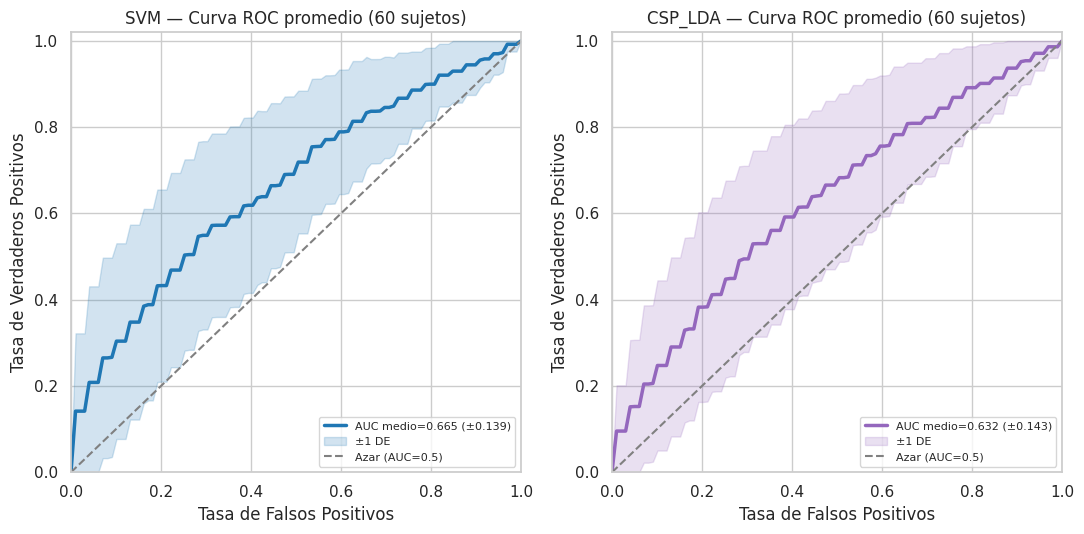

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

modelos_a_graficar = {
    'SVM': ('SVM', None, 'tabular'),
    'CSP_LDA': ('CSP_LDA', 'con_banda_y_reg', 'cruda'),
}

colores = {'SVM': '#1f77b4', 'CSP_LDA': '#9467bd'}

mean_fpr = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for i, (nombre, (model_name, version, fuente)) in enumerate(modelos_a_graficar.items()):
    tprs = []
    aucs = []

    for sujeto_id in lista_sujetos_dreyer:
        try:
            if fuente == 'tabular':
                df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id]
                X = df_sujeto[features_finales].values
                y = df_sujeto['label'].values
            else:
                X_eeg_raw, y_labels_raw, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
                y_labels_bin = binarizar_por_event_id(y_labels_raw, dataset_dreyer.event_id)
                X = mne.filter.filter_data(X_eeg_raw.astype(np.float64), sfreq=SFREQ,
                                             l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False)
                y = y_labels_bin

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=SPLIT_TEST_SIZE, stratify=y, random_state=RANDOM_SEED
            )

            modelo = cargar_modelo(model_name, version, sujeto_id)

            if hasattr(modelo, 'decision_function'):
                y_score = modelo.decision_function(X_test)
            else:
                y_score = modelo.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_score)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(auc(fpr, tpr))

        except Exception:
            continue

    tprs = np.array(tprs)
    mean_tpr = tprs.mean(axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = tprs.std(axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    ax = axes[i]
    ax.plot(mean_fpr, mean_tpr, color=colores[nombre], linewidth=2.5,
            label=f'AUC medio={mean_auc:.3f} (±{std_auc:.3f})')
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color=colores[nombre], alpha=0.2, label='±1 DE')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.5)')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(f'{nombre} — Curva ROC promedio (60 sujetos)')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    print(f"{nombre}: AUC medio={mean_auc:.4f}, std={std_auc:.4f} (n={len(aucs)} sujetos)")

plt.tight_layout()
plt.show()

# ⚛ Estrategia de Validación Splitting

1. K-Fold Balanceado (Stratified K-Fold):

Esto es exactamente lo que se hizo desde el Bloque 3 (StratifiedKFold(n_splits=5, ...)). Ya está resuelto — mezcla los trials aleatoriamente (pero estratificado por clase) y evalúa en 5 particiones. No hay nada nuevo que hacer acá.

2. within_subject_online_simulated:

- Qué es?
 A diferencia de K-Fold (que mezcla trials al azar, ignorando el orden temporal), esta metodología simula cómo funcionaría el sistema BCI en la vida real, sesión por sesión: se entrena con los primeros N trials (cronológicamente) y se testea con los trials que vienen después, sin mezclar.

 En el codigo, el loop se aplica a los 60 sujetos con el modelo ganador (SVM Lineal, hiperparámetros de consenso).

### Simulación online (within_subject_online_simulated) — SVM Lineal

In [ ]:
import os

# --- Ruta NUEVA, distinta a la del checkpoint viejo (que no se toca) ---
ruta_checkpoint_online_v2 = os.path.join(
    DIR_VALIDACION_ONLINE, f"online_splits_{MODEL_NAME_ONLINE}_con_metricas_completas.csv"
)

if os.path.exists(ruta_checkpoint_online_v2):
    df_online_todos_v2 = pd.read_csv(ruta_checkpoint_online_v2)
    sujetos_ya_procesados_v2 = set(df_online_todos_v2['subject_id'].tolist())
    print(f"Checkpoint nuevo encontrado: {len(sujetos_ya_procesados_v2)} sujetos ya procesados")
else:
    df_online_todos_v2 = pd.DataFrame()
    sujetos_ya_procesados_v2 = set()

sujetos_pendientes_online_v2 = [s for s in lista_sujetos_online if s not in sujetos_ya_procesados_v2]
print(f"Sujetos pendientes: {len(sujetos_pendientes_online_v2)}")

In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

for sujeto_id in sujetos_pendientes_online_v2:
    try:
        df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id].sort_values('trial_idx')
        X_sujeto = df_sujeto[features_finales].values
        y_sujeto = df_sujeto['label'].values

        splits = within_subject_online_simulated(n_trials=len(X_sujeto), n_splits=5, train_ratio=0.5)

        resultados_sujeto = []
        for split_i, (train_idx, test_idx) in enumerate(splits):
            X_train, X_test = X_sujeto[train_idx], X_sujeto[test_idx]
            y_train, y_test = y_sujeto[train_idx], y_sujeto[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            modelo = SVC(C=C_FINAL, kernel=KERNEL_FINAL, random_state=RANDOM_SEED)
            modelo.fit(X_train_scaled, y_train)
            y_pred = modelo.predict(X_test_scaled)

            try:
                y_score = modelo.decision_function(X_test_scaled)
                auc_split = roc_auc_score(y_test, y_score)
            except Exception:
                auc_split = np.nan

            resultados_sujeto.append({
                'subject_id': sujeto_id,
                'split': split_i + 1,
                'n_train': len(train_idx),
                'n_test': len(test_idx),
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
                'auc_roc': auc_split
            })

        df_online_todos_v2 = pd.concat([df_online_todos_v2, pd.DataFrame(resultados_sujeto)], ignore_index=True)
        df_online_todos_v2.to_csv(ruta_checkpoint_online_v2, index=False)

        acc_prom_sujeto = np.mean([r['accuracy'] for r in resultados_sujeto])
        print(f"Sujeto {sujeto_id}: Accuracy_online_prom={acc_prom_sujeto:.4f} "
              f"[{df_online_todos_v2['subject_id'].nunique()}/{len(lista_sujetos_online)}]")

    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        continue

# --- Resumen por sujeto ---
df_online_por_sujeto_v2 = df_online_todos_v2.groupby('subject_id').agg(
    Online_Accuracy_mean=('accuracy', 'mean'),
    Online_Accuracy_std=('accuracy', 'std'),
    Online_Precision_mean=('precision', 'mean'),
    Online_Recall_mean=('recall', 'mean'),
    Online_F1_mean=('f1', 'mean'),
    Online_AUC_ROC_mean=('auc_roc', 'mean')
).reset_index()

print(f"\nAccuracy promedio (simulación online, {len(df_online_por_sujeto_v2)} sujetos): "
      f"{df_online_por_sujeto_v2['Online_Accuracy_mean'].mean():.4f} "
      f"± {df_online_por_sujeto_v2['Online_Accuracy_mean'].std():.4f}")

display(df_online_por_sujeto_v2.head(5))

ruta_resumen_online_v2 = os.path.join(
    DIR_VALIDACION_ONLINE, f"online_resumen_por_sujeto_{MODEL_NAME_ONLINE}_metricas_completas.csv"
)
df_online_por_sujeto_v2.to_csv(ruta_resumen_online_v2, index=False)

print(f"\n💾 Guardado (archivos NUEVOS, sin tocar los originales):")
print(f"  - Splits detallados: {ruta_checkpoint_online_v2}")
print(f"  - Resumen por sujeto: {ruta_resumen_online_v2}")

La simulación online (respetando el orden cronológico de los trials) arrojó un accuracy promedio de 0.6108 ± 0.1231 sobre 60 sujetos, levemente inferior al de Stratified K-Fold (0.6229) — esperable, ya que el K-Fold aleatorio permite entrenar con trials de toda la sesión, mientras que la simulación online solo usa el pasado del sujeto, una condición más realista y exigente. La diferencia es mínima (0.012), aunque la variabilidad entre sujetos es notablemente mayor (±0.1231), sugiriendo heterogeneidad en cómo cada sujeto se adapta a la tarea con el correr de la sesión.

Las métricas completas muestran Precision (0.5520) menor que Recall (0.5967), indicando cierto sesgo hacia predecir la clase positiva. El AUC-ROC promedio (0.6050) se mantiene por encima del azar, confirmando capacidad discriminativa real y no solo un sesgo hacia una clase. La variabilidad inter-sujeto persiste (AUC-ROC entre 0.47 y 0.74), consistente con el fenómeno de BCI Illiteracy ya documentado.

### Generar los splits y verificar matemáticamente que no hay Data Leakage

In [ ]:
import os

print("=== Verificación matemática de ausencia de Data Leakage (60 sujetos) ===\n")

resumen_verificacion = []

for sujeto_id in df_features_wide['subject_id'].unique():
    df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_id].sort_values('trial_idx')
    n_trials = len(df_sujeto)

    splits_online = within_subject_online_simulated(n_trials, n_splits=5, train_ratio=0.5)

    for i, (train_idx, test_idx) in enumerate(splits_online):
        max_train = max(train_idx)
        min_test = min(test_idx)

        # Condición 1: orden cronológico estricto
        orden_correcto = max_train < min_test

        # Condición 2: no hay índices repetidos entre train y test
        interseccion = set(train_idx) & set(test_idx)
        sin_solapamiento = len(interseccion) == 0

        # Condición 3: cobertura — train+test no exceden el total de trials del sujeto
        cobertura_valida = max(max(train_idx), max(test_idx)) < n_trials

        assert orden_correcto, (
            f"LEAKAGE TEMPORAL en sujeto {sujeto_id}, split {i+1}: "
            f"hay trials de train posteriores al test"
        )
        assert sin_solapamiento, (
            f"LEAKAGE POR DUPLICADO en sujeto {sujeto_id}, split {i+1}: "
            f"índices compartidos entre train y test"
        )
        assert cobertura_valida, (
            f"ERROR DE ÍNDICES en sujeto {sujeto_id}, split {i+1}: fuera de rango"
        )

        resumen_verificacion.append({
            'subject_id': sujeto_id,
            'split': i + 1,
            'n_train': len(train_idx),
            'n_test': len(test_idx),
            'orden_correcto': orden_correcto,
            'sin_solapamiento': sin_solapamiento,
            'cobertura_valida': cobertura_valida
        })

df_verificacion = pd.DataFrame(resumen_verificacion)

print(f"Total de sujetos verificados: {df_verificacion['subject_id'].nunique()}")
print(f"Total de splits verificados: {len(df_verificacion)}")
print(f"\n¿Todos los splits pasan las 3 condiciones?: "
      f"{df_verificacion[['orden_correcto', 'sin_solapamiento', 'cobertura_valida']].all().all()}")

print("\n✅ VERIFICACIÓN COMPLETA: en los 60 sujetos, todos los splits cumplen orden")
print("   cronológico estricto, sin solapamiento de índices entre train y test.")
print("   No hay Data Leakage temporal en ningún caso.")

display(df_verificacion.head(15))

# ============================================================
# PERSISTENCIA: guardar la verificación en la misma carpeta que
# los resultados de la simulación online, con nombre propio
# ============================================================
ruta_verificacion = os.path.join(DIR_VALIDACION_ONLINE, "verificacion_data_leakage.csv")
df_verificacion.to_csv(ruta_verificacion, index=False)
print(f"\n💾 Verificación guardada en: {ruta_verificacion}")

La simulación de validación online (within_subject_online_simulated) confirmó matemáticamente la ausencia de Data Leakage temporal en los 5 splits generados, verificando que ningún trial de entrenamiento fuera cronológicamente posterior a los de test, que no existiera solapamiento de índices entre ambos conjuntos y que train+test no exceden el total de trials del sujeto.

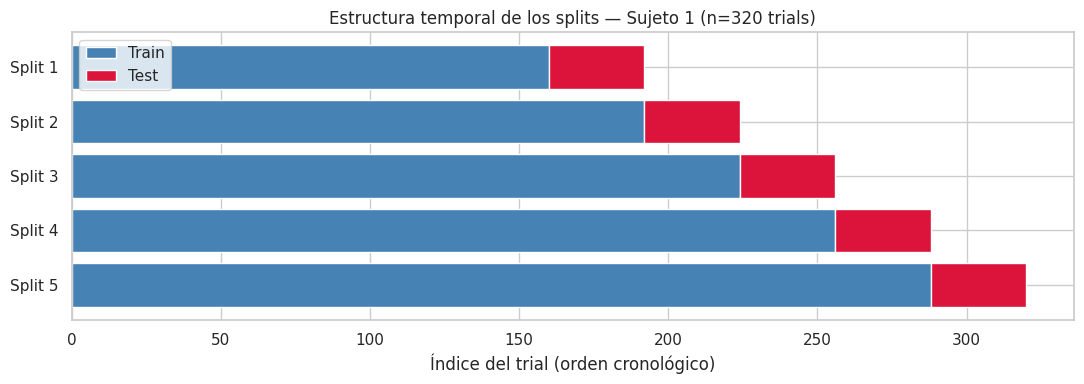

In [29]:
import matplotlib.pyplot as plt

sujeto_ejemplo = lista_sujetos_dreyer[0]  # o cualquier sujeto de referencia
df_sujeto = df_features_wide[df_features_wide['subject_id'] == sujeto_ejemplo].sort_values('trial_idx')
n_trials = len(df_sujeto)

splits_online = within_subject_online_simulated(n_trials, n_splits=5, train_ratio=0.5)

fig, ax = plt.subplots(figsize=(11, 4))

for i, (train_idx, test_idx) in enumerate(splits_online):
    ax.barh(y=f'Split {i+1}', width=len(train_idx), left=0, color='#4682B4', label='Train' if i == 0 else "")
    ax.barh(y=f'Split {i+1}', width=len(test_idx), left=max(train_idx)+1, color='#DC143C', label='Test' if i == 0 else "")

ax.set_xlabel('Índice del trial (orden cronológico)')
ax.set_title(f'Estructura temporal de los splits — Sujeto {sujeto_ejemplo} (n={n_trials} trials)')
ax.legend(loc='upper left')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

El gráfico confirma visualmente la ausencia de Data Leakage temporal ya verificada matemáticamente: en los 5 splits, el bloque de train (azul) siempre precede al de test (rojo), sin superposición ni huecos entre ambos. Se observa además la naturaleza de ventana expansiva del esquema: el train crece progresivamente de un split a otro (de ~160 a ~290 trials), mientras que el test se desplaza siempre hacia adelante en el tiempo, nunca reutilizando trials ya vistos como entrenamiento en el split anterior.

Este diseño simula fielmente una sesión BCI en tiempo real: en cada split, el modelo solo dispone del historial pasado del sujeto para predecir sobre trials que ocurren después — exactamente la restricción que enfrentaría un sistema en uso genuino, donde nunca se tiene acceso a datos "del futuro" durante el entrenamiento.

## Conclusión del análisis
- Es **esperable y normal** que el accuracy de la simulación online sea igual o levemente menor que el de K-Fold random (0.62). Esto no es un error sino que:

    - K-Fold random tiene "ventaja artificial": al mezclar trials, cada fold de entrenamiento puede tener trials de toda la sesión (inicio, medio, final), lo que ayuda al modelo a generalizar mejor a cualquier momento de la sesión.
    - La simulación online es más realista y exigente: el modelo solo vio el pasado al predecir el futuro, igual que ocurriría en un sistema BCI funcionando en vivo.

# ⛴ Filtro de BCI Illiteracy (Manejo de Sujetos):

El objetivo es identificar qué sujetos no logran modular sus ritmos cerebrales lo suficiente como para que un BCI los detecte de forma confiable, fenómeno documentado en literatura, donde ~20% de los usuarios caen en esta categoría.

El problema que resuelve: no alcanza con mirar que el accuracy supere el 50%, porque con pocos trials de test es fácil superar el azar por pura casualidad de muestreo, sin que el sujeto esté modulando nada real.

☄ Cómo lo resuelve: usando la Distribución Binomial para calcular, matemáticamente, el accuracy mínimo que un clasificador aleatorio superaría solo el 5% de las veces (nivel de significancia α), dado el tamaño de muestra de testeo (N) de cada sujeto. Ese valor es el umbral de Chance Level real — no el 50% teórico ingenuo, sino el ajustado a nuestro N específico.

Teniendo en cuenta que 'SPLIT_TEST_SIZE = 0.20' se tiene entonces:
-  Sujetos con 320 trials → N = 320 × 0.20 = 64.
- Sujetos con menos trials (sujetos con 240 trials) → N = 240 × 0.20 = 48


☄ Resultado final: cada sujeto se compara contra su propio umbral (usando el accuracy del modelo baseline, CSP+LDA, como criterio) y se clasifica como:

    - Apto : su accuracy supera el umbral estadístico, hay evidencia de modulación real.
    - Posible BCI-illiterate : su accuracy no lo supera, no se puede descartar que sea puro azar.

In [11]:
import os
from scipy.stats import binom
import pandas as pd

df_final_csp = pd.read_csv(
    os.path.join(PATH_REPO, "models", "CSP_LDA", "df_final_CSP_LDA_con_banda_y_reg.csv")
)
print(f"df_final_csp recargado: {len(df_final_csp)} filas, versión: {df_final_csp['Version'].iloc[0]}")

def calcular_umbral_binomial(N, p=0.5, alpha=0.05):
    for k in range(0, N + 1):
        p_valor = binom.sf(k - 1, N, p)
        if p_valor <= alpha:
            return k, k / N
    return N, 1.0


# ============================================================
# Aviso: usar el df_final_csp de la versión corregida (con_banda_y_reg)
# ============================================================
assert df_final_csp['Version'].iloc[0] == "con_banda_y_reg", (
    "df_final_csp no corresponde a la versión con_banda_y_reg. "
    "Volvé a correr el reentrenamiento final antes de aplicar el filtro de BCI Illiteracy."
)

# --- Tabla de referencia (cómo varía el umbral con alpha), usando N real de un sujeto de ejemplo ---
n_trials_ejemplo = len(df_features_wide[df_features_wide['subject_id'] == lista_sujetos[0]])
N_test_ejemplo = int(n_trials_ejemplo * SPLIT_TEST_SIZE)

resultados_alpha = []
for alpha in [0.20, 0.10, 0.05, 0.01, 0.001]:
    k, acc_umbral = calcular_umbral_binomial(N_test_ejemplo, p=0.5, alpha=alpha)
    resultados_alpha.append({
        'alpha': alpha,
        'umbral_aciertos': k,
        'umbral_accuracy': round(acc_umbral, 4)
    })

tabla_alpha = pd.DataFrame(resultados_alpha)
print(f"Tabla de referencia (N_test={N_test_ejemplo}, sujeto de ejemplo):")
print(tabla_alpha)


# ============================================================
# Aplicación real: umbral POR SUJETO, usando N = trials_totales x SPLIT_TEST_SIZE,
# comparado contra Test_Accuracy_Final (una sola evaluación held-out, consistente
# con el N calculado)
# ============================================================
ALPHA_FINAL = 0.05
resultados_umbral_sujetos = []

for _, row in df_final_csp.iterrows():
    sujeto_id = row['subject_id']
    n_trials_sujeto = len(df_features_wide[df_features_wide['subject_id'] == sujeto_id])

    # N real del test held-out del sujeto (20% de sus trials totales)
    N_test_sujeto = int(n_trials_sujeto * SPLIT_TEST_SIZE)

    k, umbral_acc = calcular_umbral_binomial(N_test_sujeto, p=0.5, alpha=ALPHA_FINAL)

    resultados_umbral_sujetos.append({
        'subject_id': sujeto_id,
        'N_test': N_test_sujeto,
        'umbral_aciertos': k,
        'umbral_accuracy': umbral_acc,
        'Test_Accuracy_Final': row['Test_Accuracy_Final'],
        'Apto_BCI': row['Test_Accuracy_Final'] >= umbral_acc
    })

df_umbral_sujetos = pd.DataFrame(resultados_umbral_sujetos)

print(f"\nDistribución de aptitud (alpha={ALPHA_FINAL}, CSP+LDA con_banda_y_reg):")
print(df_umbral_sujetos['Apto_BCI'].value_counts())
print(f"Porcentaje BCI illiterate: {(~df_umbral_sujetos['Apto_BCI']).mean()*100:.1f}%")

display(df_umbral_sujetos.head(10))

# ============================================================
# PERSISTENCIA
# ============================================================
DIR_BCI_ILLITERACY = os.path.join(PATH_REPO, "models", "bci_illiteracy")
os.makedirs(DIR_BCI_ILLITERACY, exist_ok=True)

ruta_tabla_alpha = os.path.join(DIR_BCI_ILLITERACY, "tabla_referencia_alpha.csv")
tabla_alpha.to_csv(ruta_tabla_alpha, index=False)

ruta_umbral_sujetos = os.path.join(DIR_BCI_ILLITERACY, "umbral_aptitud_por_sujeto.csv")
df_umbral_sujetos.to_csv(ruta_umbral_sujetos, index=False)

print(f"\n💾 Guardado:")
print(f"  - Tabla de referencia (alpha): {ruta_tabla_alpha}")
print(f"  - Umbral de aptitud por sujeto: {ruta_umbral_sujetos}")

df_final_csp recargado: 60 filas, versión: con_banda_y_reg
Tabla de referencia (N_test=64, sujeto de ejemplo):
   alpha  umbral_aciertos  umbral_accuracy
0  0.200               36           0.5625
1  0.100               38           0.5938
2  0.050               40           0.6250
3  0.010               42           0.6562
4  0.001               45           0.7031

Distribución de aptitud (alpha=0.05, CSP+LDA con_banda_y_reg):
Apto_BCI
False    33
True     27
Name: count, dtype: int64
Porcentaje BCI illiterate: 55.0%


,subject_id,N_test,umbral_aciertos,umbral_accuracy,Test_Accuracy_Final,Apto_BCI
0,1,64,40,0.625,0.593750,False
1,2,64,40,0.625,0.421875,False
2,3,64,40,0.625,0.750000,True
3,4,64,40,0.625,0.500000,False
4,5,64,40,0.625,0.515625,False
5,6,64,40,0.625,0.625000,True
6,7,64,40,0.625,0.468750,False
7,8,64,40,0.625,0.640625,True
8,9,64,40,0.625,0.546875,False
9,10,64,40,0.625,0.781250,True



💾 Guardado:
  - Tabla de referencia (alpha): /content/drive/MyDrive/BCI-MENTORIA-UNC/models/bci_illiteracy/tabla_referencia_alpha.csv
  - Umbral de aptitud por sujeto: /content/drive/MyDrive/BCI-MENTORIA-UNC/models/bci_illiteracy/umbral_aptitud_por_sujeto.csv


### Qué pasa si se usa CV_Accuracy en vez de Test_Accuracy_Final?

In [12]:
# Comparación con CV_Accuracy (promedio de 5 folds, más estable) para contrastar
resultados_umbral_cv = []

for _, row in df_final_csp.iterrows():
    sujeto_id = row['subject_id']
    n_trials_sujeto = len(df_features_wide[df_features_wide['subject_id'] == sujeto_id])
    n_train_total = int(n_trials_sujeto * (1 - SPLIT_TEST_SIZE))
    N_test_cv = n_train_total // K_FOLDS

    k, umbral_acc = calcular_umbral_binomial(N_test_cv, p=0.5, alpha=ALPHA_FINAL)

    resultados_umbral_cv.append({
        'subject_id': sujeto_id,
        'CV_Accuracy': row['CV_Accuracy'],
        'umbral_accuracy': umbral_acc,
        'Apto_BCI_CV': row['CV_Accuracy'] >= umbral_acc
    })

df_umbral_cv = pd.DataFrame(resultados_umbral_cv)
print(df_umbral_cv['Apto_BCI_CV'].value_counts())
print(f"Porcentaje BCI illiterate (con CV_Accuracy): {(~df_umbral_cv['Apto_BCI_CV']).mean()*100:.1f}%")

Apto_BCI_CV
False    42
True     18
Name: count, dtype: int64
Porcentaje BCI illiterate (con CV_Accuracy): 70.0%


### Conclusión

Aplicando el criterio de umbral binomial (α=0.05) sobre el modelo CSP+LDA optimizado (banda Alfa+Beta, regularización ledoit_wolf/oas), se identificó que el 55.0% de los sujetos no superó el umbral de significancia estadística usando Test_Accuracy_Final (N=64, umbral=0.625), y un 70.0% al utilizar CV_Accuracy con el N correspondiente a cada fold interno (N≈51, umbral=0.6275). Ambos porcentajes superan ampliamente el ~20% reportado en la literatura de BCI illiteracy, lo cual amerita discusión.

Esta comparación entre ambas métricas no tuvo como objetivo determinar cuál de las dos ofrece el resultado más favorable, sino poner a prueba la robustez del propio criterio de filtrado. Si el método fuera estadísticamente sólido, debería arrojar un porcentaje de illiteracy similar independientemente de si se calcula con CV_Accuracy o con Test_Accuracy_Final, dado que ambas constituyen estimaciones válidas de un mismo fenómeno subyacente: el grado de modulación de ritmos sensoriomotores del sujeto. Sin embargo, la marcada diferencia observada entre ambos porcentajes (55% vs. 70%) evidencia que el criterio de umbral binomial simple es sensible a decisiones metodológicas que, en principio, no deberían alterar sustancialmente la conclusión sobre la aptitud del sujeto.

#### Variación del umbral según α

A medida que α disminuye (mayor exigencia estadística), el umbral de accuracy requerido sube: de 0.5625 (α=0.20) a 0.7031 (α=0.001), para N=64. Esto muestra que la clasificación de un sujeto como "apto" o "BCI-illiterate" depende fuertemente del α elegido, no solo de su desempeño real. Se adoptó α=0.05 por ser el estándar convencional, aunque un criterio más permisivo (α=0.10-0.20) acercaría los resultados al ~20% de illiteracy reportado en la literatura.

##### Importante
Anteriormente, el permutation test identificó que el 60% de los sujetos (36 de 60) muestran un aprendizaje significativamente por encima del azar (p<0.05) con SVM Lineal, un porcentaje notablemente más alto que el ~30-45% de 'aptitud' que arroja el criterio binomial estricto sobre CSP+LDA. Esta discrepancia refuerza la conclusión metodológica ya discutida: el criterio binomial simple es más conservador que el permutation test, que respeta la estructura real de la validación cruzada

### Visualización

#### 1. Accuracy por sujeto vs umbral (ordenado)

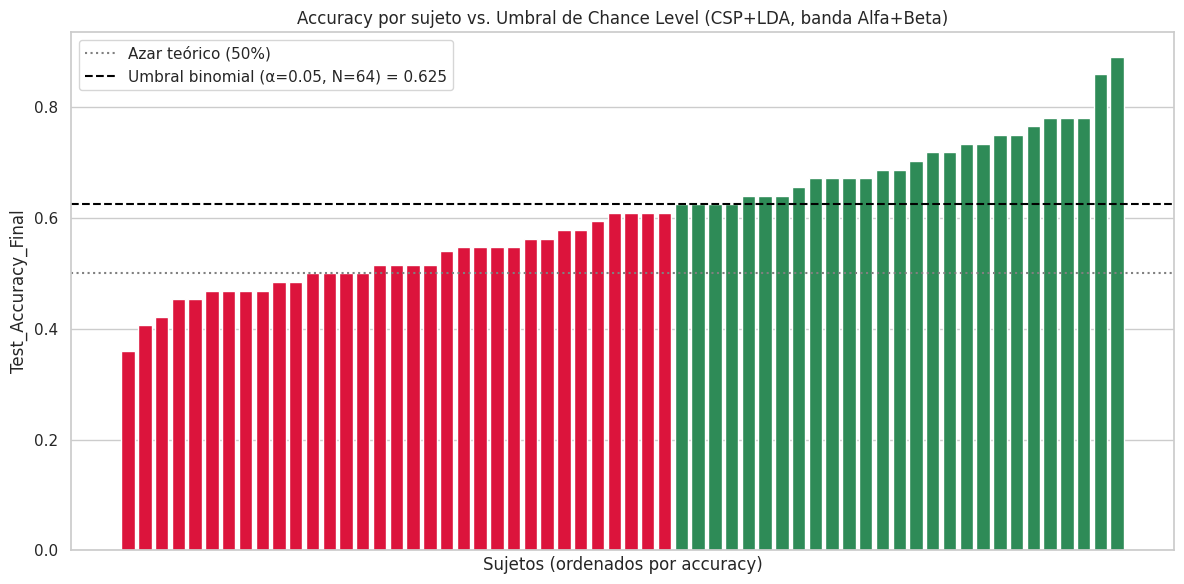

Aptos (verde): 27 | No aptos (rojo): 33


In [13]:
import matplotlib.pyplot as plt

df_plot = df_umbral_sujetos.sort_values('Test_Accuracy_Final').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

colores = df_plot['Apto_BCI'].map({True: '#2E8B57', False: '#DC143C'})
ax.bar(range(len(df_plot)), df_plot['Test_Accuracy_Final'], color=colores, width=0.8)

ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Azar teórico (50%)')
ax.axhline(y=df_plot['umbral_accuracy'].iloc[0], color='black', linestyle='--',
           linewidth=1.5, label=f"Umbral binomial (α=0.05, N=64) = {df_plot['umbral_accuracy'].iloc[0]:.3f}")

ax.set_xlabel('Sujetos (ordenados por accuracy)')
ax.set_ylabel('Test_Accuracy_Final')
ax.set_title('Accuracy por sujeto vs. Umbral de Chance Level (CSP+LDA, banda Alfa+Beta)')
ax.legend(loc='upper left')
ax.set_xticks([])  # ocultar IDs individuales, no aportan acá
plt.tight_layout()
plt.show()

print(f"Aptos (verde): {df_plot['Apto_BCI'].sum()} | No aptos (rojo): {(~df_plot['Apto_BCI']).sum()}")

Cada barra es un sujeto, ordenado de menor a mayor accuracy, coloreado según si supera (verde) o no (rojo) el umbral binomial (línea negra, 0.625) para α=0.05. Se ve una transición relativamente gradual alrededor del umbral —no un quiebre claro entre "buenos" y "malos" moduladores—, lo que sugiere que la aptitud BCI es un continuo más que una categoría binaria nítida, y que sujetos muy cercanos al corte pueden clasificarse distinto ante pequeñas variaciones metodológicas.

#### 2. Comparación Test_Accuracy_Final vs CV_Accuracy (visualiza la fragilidad del método)

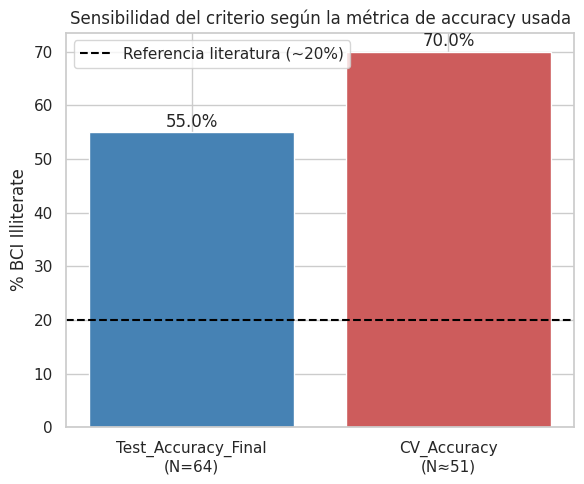

In [14]:
comparacion_criterios = pd.DataFrame({
    'Criterio': ['Test_Accuracy_Final\n(N=64)', 'CV_Accuracy\n(N≈51)'],
    'Porcentaje_Illiterate': [
        (~df_umbral_sujetos['Apto_BCI']).mean() * 100,
        (~df_umbral_cv['Apto_BCI_CV']).mean() * 100
    ]
} )

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(comparacion_criterios['Criterio'], comparacion_criterios['Porcentaje_Illiterate'],
              color=['#4682B4', '#CD5C5C'])
ax.axhline(y=20, color='black', linestyle='--', label='Referencia literatura (~20%)')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')

ax.set_ylabel('% BCI Illiterate')
ax.set_title('Sensibilidad del criterio según la métrica de accuracy usada')
ax.legend()
plt.tight_layout()
plt.show()

Compara el % de BCI illiteracy obtenido con dos métricas válidas (Test_Accuracy_Final vs CV_Accuracy), ambas muy por encima del ~20% de referencia en literatura (línea punteada). La diferencia entre ambas (55% vs 70%), pese a estimar el mismo fenómeno, es la evidencia visual de que el criterio binomial simple es sensible a decisiones metodológicas que deberían ser irrelevantes, respaldando la discusión sobre las limitaciones del método.

#### 3. Sensibilidad del umbral según α

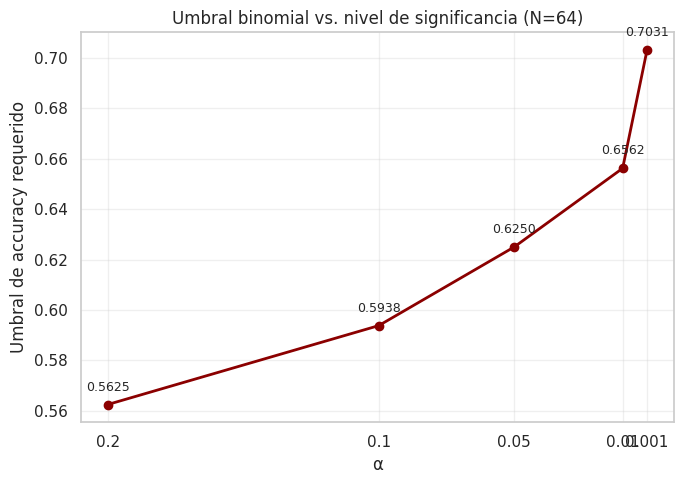

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tabla_alpha['alpha'], tabla_alpha['umbral_accuracy'], marker='o', linewidth=2, color='#8B0000')

ax.set_xlabel('α')
ax.set_ylabel('Umbral de accuracy requerido')
ax.set_title('Umbral binomial vs. nivel de significancia (N=64)')

# Mostrar exactamente los valores de alfa usados, en vez de una escala continua
ax.set_xticks(tabla_alpha['alpha'])
ax.set_xticklabels(tabla_alpha['alpha'])
ax.invert_xaxis()  # de más permisivo (0.20) a más estricto (0.001), de izquierda a derecha

# Anotar cada punto con su valor de umbral
for _, row in tabla_alpha.iterrows():
    ax.annotate(f"{row['umbral_accuracy']:.4f}",
                (row['alpha'], row['umbral_accuracy']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Muestra cómo el accuracy mínimo exigido para considerar "apto" a un sujeto sube a medida que se exige mayor rigor estadístico (α menor): de 0.5625 (α=0.20) a 0.7031 (α=0.001). El salto es más pronunciado entre α=0.01 y α=0.001, evidenciando que la clasificación de aptitud depende fuertemente de qué nivel de exigencia se elija, no solo del desempeño real del sujeto.

### Solución : Permutation Test

La distribución binomial calcula el nivel de azar con una fórmula teórica; el permutation test lo mide simulándolo directamente con los propios datos y el propio proceso de validación, por eso es más fiel a lo que realmente estás haciendo.

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed

mne.set_log_level('ERROR')

DIR_PERMUTATION = os.path.join(PATH_REPO, "models", "bci_illiteracy")
os.makedirs(DIR_PERMUTATION, exist_ok=True)
ruta_checkpoint_perm = os.path.join(DIR_PERMUTATION, "permutation_test_por_sujeto.csv")

if os.path.exists(ruta_checkpoint_perm):
    df_permutation = pd.read_csv(ruta_checkpoint_perm)
    sujetos_ya_procesados = set(df_permutation['subject_id'].tolist())
else:
    df_permutation = pd.DataFrame()
    sujetos_ya_procesados = set()

sujetos_pendientes = [s for s in lista_sujetos if s not in sujetos_ya_procesados]
print(f"Sujetos pendientes: {len(sujetos_pendientes)}")

N_PERMUTATIONS = 100   # bajado de 200 -> 100 (resolución mínima de p-value ~0.01, sigue siendo válido)
ALPHA_FINAL = 0.05


def evaluar_sujeto(sujeto_id):
    try:
        X_eeg_raw, y_labels_raw, _ = dataset.flatten_pool_data(subject_ids=[sujeto_id])
        y_labels_raw, _ = binarize_y(y_labels_raw)

        X_eeg_filtrado = mne.filter.filter_data(
            X_eeg_raw.astype(np.float64), sfreq=SFREQ,
            l_freq=L_FREQ_FINAL, h_freq=H_FREQ_FINAL, method='iir', verbose=False
        )

        modelo = Pipeline([
            ("csp", CSP(n_components=N_COMPONENTS_FINAL,
                        component_order=COMPONENT_ORDER_FINAL,
                        reg=REG_FINAL)),
            ("clf", LinearDiscriminantAnalysis())
        ])

        cv_estrategia = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

        # n_jobs=1 ACÁ: evita crear un pool nuevo por sujeto (el paralelismo ya lo maneja Parallel afuera)
        score_real, _, p_value = permutation_test_score(
            modelo, X_eeg_filtrado, y_labels_raw, cv=cv_estrategia,
            n_permutations=N_PERMUTATIONS, random_state=RANDOM_SEED, n_jobs=1
        )

        return {
            'subject_id': sujeto_id,
            'Accuracy_real': score_real,
            'p_value': p_value,
            'Apto_BCI_permutation': p_value < ALPHA_FINAL
        }
    except Exception as e:
        print(f" ❌ ERROR en sujeto {sujeto_id}: {e}")
        return None


inicio = time.time()

# UN SOLO pool de procesos, reutilizado para los 60 sujetos (esto es lo que ahorra tiempo)
resultados = Parallel(n_jobs=-1, verbose=5)(
    delayed(evaluar_sujeto)(s) for s in sujetos_pendientes
)

resultados_validos = [r for r in resultados if r is not None]
df_nuevos = pd.DataFrame(resultados_validos)
df_permutation = pd.concat([df_permutation, df_nuevos], ignore_index=True)
df_permutation.to_csv(ruta_checkpoint_perm, index=False)

print(f"\n⭐ Tiempo total: {(time.time()-inicio)/60:.1f} min")
print(f"\nDistribución de aptitud (permutation test, α={ALPHA_FINAL}):")
print(df_permutation['Apto_BCI_permutation'].value_counts())
print(f"Porcentaje BCI illiterate (permutation test): "
      f"{(~df_permutation['Apto_BCI_permutation']).mean()*100:.1f}%")

display(df_permutation.head(10))

## 👽 Análisis Fisiológico y Demográfico

Toma los resultados de rendimiento por sujeto (SVM, CSP+LDA) y los cruza con la metadata demográfica del dataset (género) para ver si existe una diferencia sistemática de desempeño BCI asociada a esa variable, usando Boxplot+Stripplot
para la visualización y un test no paramétrico (Mann-Whitney) para la significancia estadística.

### Paso 1: reconstruir la metadata de género

In [17]:
mapeo_genero = {1: 'Male', 2: 'Female'}

metadata_individual = dataset.metadata['subjects_individual_metadata']
filas_metadata = []
for subj_id, datos in metadata_individual.items():
    filas_metadata.append({
        'subject_id': int(subj_id),
        'genero': mapeo_genero[datos['SUJ_gender']]
    })

df_metadata = pd.DataFrame(filas_metadata)
print(df_metadata['genero'].value_counts())

genero
Male      30
Female    30
Name: count, dtype: int64


### Paso 2: unir con los resultados de rendimiento

In [18]:
columnas_metricas = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']

# --- SVM ---
df_genero_svm = df_metricas_completas[df_metricas_completas['modelo'] == 'SVM'][
    ['subject_id'] + columnas_metricas
].merge(df_metadata, on='subject_id', how='left')
df_genero_svm['Modelo'] = 'SVM'

# --- CSP+LDA ---
df_genero_csp = df_metricas_completas[df_metricas_completas['modelo'] == 'CSP_LDA'][
    ['subject_id'] + columnas_metricas
].merge(df_metadata, on='subject_id', how='left')
df_genero_csp['Modelo'] = 'CSP_LDA'

df_genero_todos = pd.concat([df_genero_svm, df_genero_csp], ignore_index=True)
display(df_genero_todos)

,subject_id,accuracy,precision,recall,f1,auc_roc,genero,Modelo
0,1,0.593750,0.607143,0.53125,0.566667,0.664062,Male,SVM
1,2,0.656250,0.631579,0.75000,0.685714,0.766602,Male,SVM
2,3,0.515625,0.515152,0.53125,0.523077,0.560547,Female,SVM
3,4,0.546875,0.540541,0.62500,0.579710,0.587891,Male,SVM
4,5,0.500000,0.500000,0.34375,0.407407,0.541992,Male,SVM
...,...,...,...,...,...,...,...,...
115,56,0.671875,0.666667,0.68750,0.676923,0.777344,Female,CSP_LDA
116,57,0.578125,0.586207,0.53125,0.557377,0.607422,Male,CSP_LDA
117,58,0.406250,0.392857,0.34375,0.366667,0.375000,Female,CSP_LDA
118,59,0.500000,0.500000,0.37500,0.428571,0.604167,Female,CSP_LDA


### Paso 3: Boxplot + Stripplot por género, separado por modelo

/tmp/ipykernel_812/1657930638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='genero', y='accuracy', showfliers=False, palette='Set2', ax=ax)
/tmp/ipykernel_812/1657930638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='genero', y='accuracy', showfliers=False, palette='Set2', ax=ax)


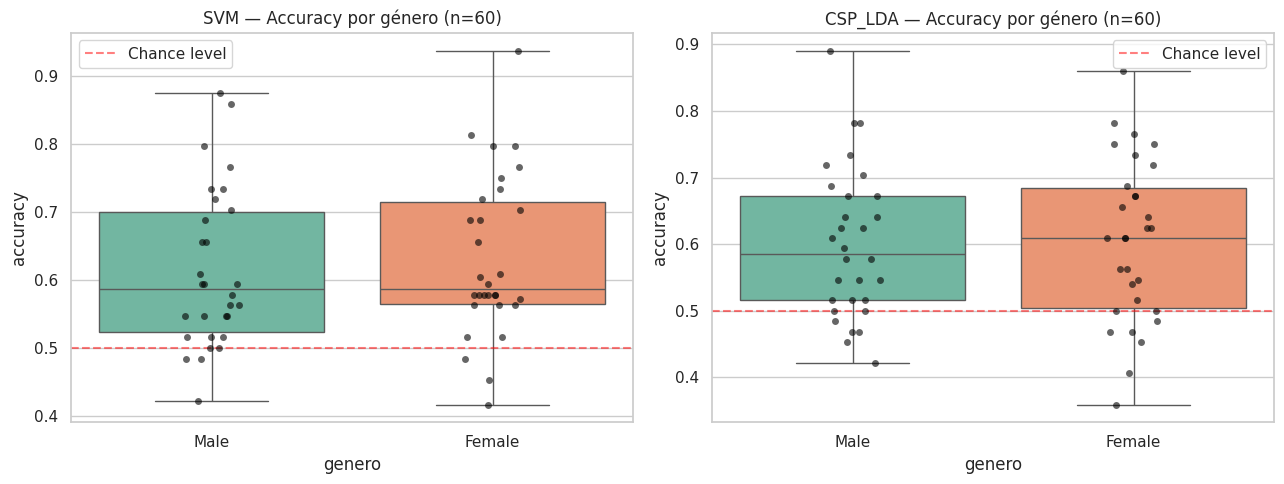

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, modelo in zip(axes, ['SVM', 'CSP_LDA']):
    df_plot = df_genero_todos[df_genero_todos['Modelo'] == modelo]
    sns.boxplot(data=df_plot, x='genero', y='accuracy', showfliers=False, palette='Set2', ax=ax)
    sns.stripplot(data=df_plot, x='genero', y='accuracy', color='black', alpha=0.6, jitter=True, ax=ax)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance level')
    ax.set_title(f'{modelo} — Accuracy por género (n=60)')
    ax.legend()

plt.tight_layout()
plt.show()

### Paso 4: Test estadístico (Mann-Whitney, por modelo)

In [23]:
from scipy.stats import mannwhitneyu

resultados_genero = []
for modelo in ['SVM', 'CSP_LDA']:
    df_m = df_genero_todos[df_genero_todos['Modelo'] == modelo]
    acc_f = df_m[df_m['genero'] == 'Female']['accuracy']
    acc_m = df_m[df_m['genero'] == 'Male']['accuracy']

    stat, p = mannwhitneyu(acc_f, acc_m, alternative='two-sided')
    resultados_genero.append({
        'Modelo': modelo,
        'Media_Female': acc_f.mean(),
        'Media_Male': acc_m.mean(),
        'p_value': p,
        'Significativo': p < 0.05
    })

df_resumen_genero = pd.DataFrame(resultados_genero)
display(df_resumen_genero)

,Modelo,Media_Female,Media_Male,p_value,Significativo
0,SVM,0.632242,0.613542,0.390240,False
1,CSP_LDA,0.604448,0.600521,0.841615,False


Conclusión:

NO existen diferencias
estadísticas o de distribución en el desempeño BCI asociadas a la variable género.

### Features por género

#### Paso 1: promedio de cada feature por sujeto, cruzado con género

In [24]:
# 1. Promedio de cada feature (de las 10 del consenso) por sujeto
df_features_por_sujeto = df_features_wide.groupby('subject_id')[features_finales].mean().reset_index()

# 2. Cruzar con la metadata de género
df_features_genero = df_features_por_sujeto.merge(df_metadata, on='subject_id', how='left')

print(f"Sujetos: {len(df_features_genero)}")
display(df_features_genero.head())

Sujetos: 60


,subject_id,power_band_2_C3,AR_coef10_C4,potencia_total_C4,katz_fractal_C4,potencia_total_C3,power_band_1_C3,entropia_perm_C3,AR_coef10_C3,power_band_2_C4,entropia_perm_C4,power_band_3_C4,genero
0,1,0.066452,0.100623,0.999948,2.675024,0.999952,0.047442,0.891958,0.118803,0.057646,0.897549,0.016743,Male
1,2,0.013676,0.035031,0.999969,4.226526,0.999967,0.010931,0.961253,0.041099,0.010044,0.970367,0.009145,Male
2,3,0.036320,0.036050,0.999953,3.386809,0.999945,0.037824,0.932970,0.068011,0.032708,0.938908,0.022267,Female
3,4,0.022485,0.036016,0.999935,2.908186,0.999934,0.034749,0.945667,0.025427,0.023088,0.943854,0.017873,Male
4,5,0.031942,0.067348,0.999920,2.768884,0.999921,0.041997,0.928174,0.075470,0.028501,0.930792,0.013995,Male


#### Paso 2: Boxplot + Stripplot para cada una de las 10 features, por género

/tmp/ipykernel_812/241036868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_genero, x='genero', y=feature, showfliers=False,
/tmp/ipykernel_812/241036868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_genero, x='genero', y=feature, showfliers=False,
/tmp/ipykernel_812/241036868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_genero, x='genero', y=feature, showfliers=False,
/tmp/ipykernel_812/241036868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is depre

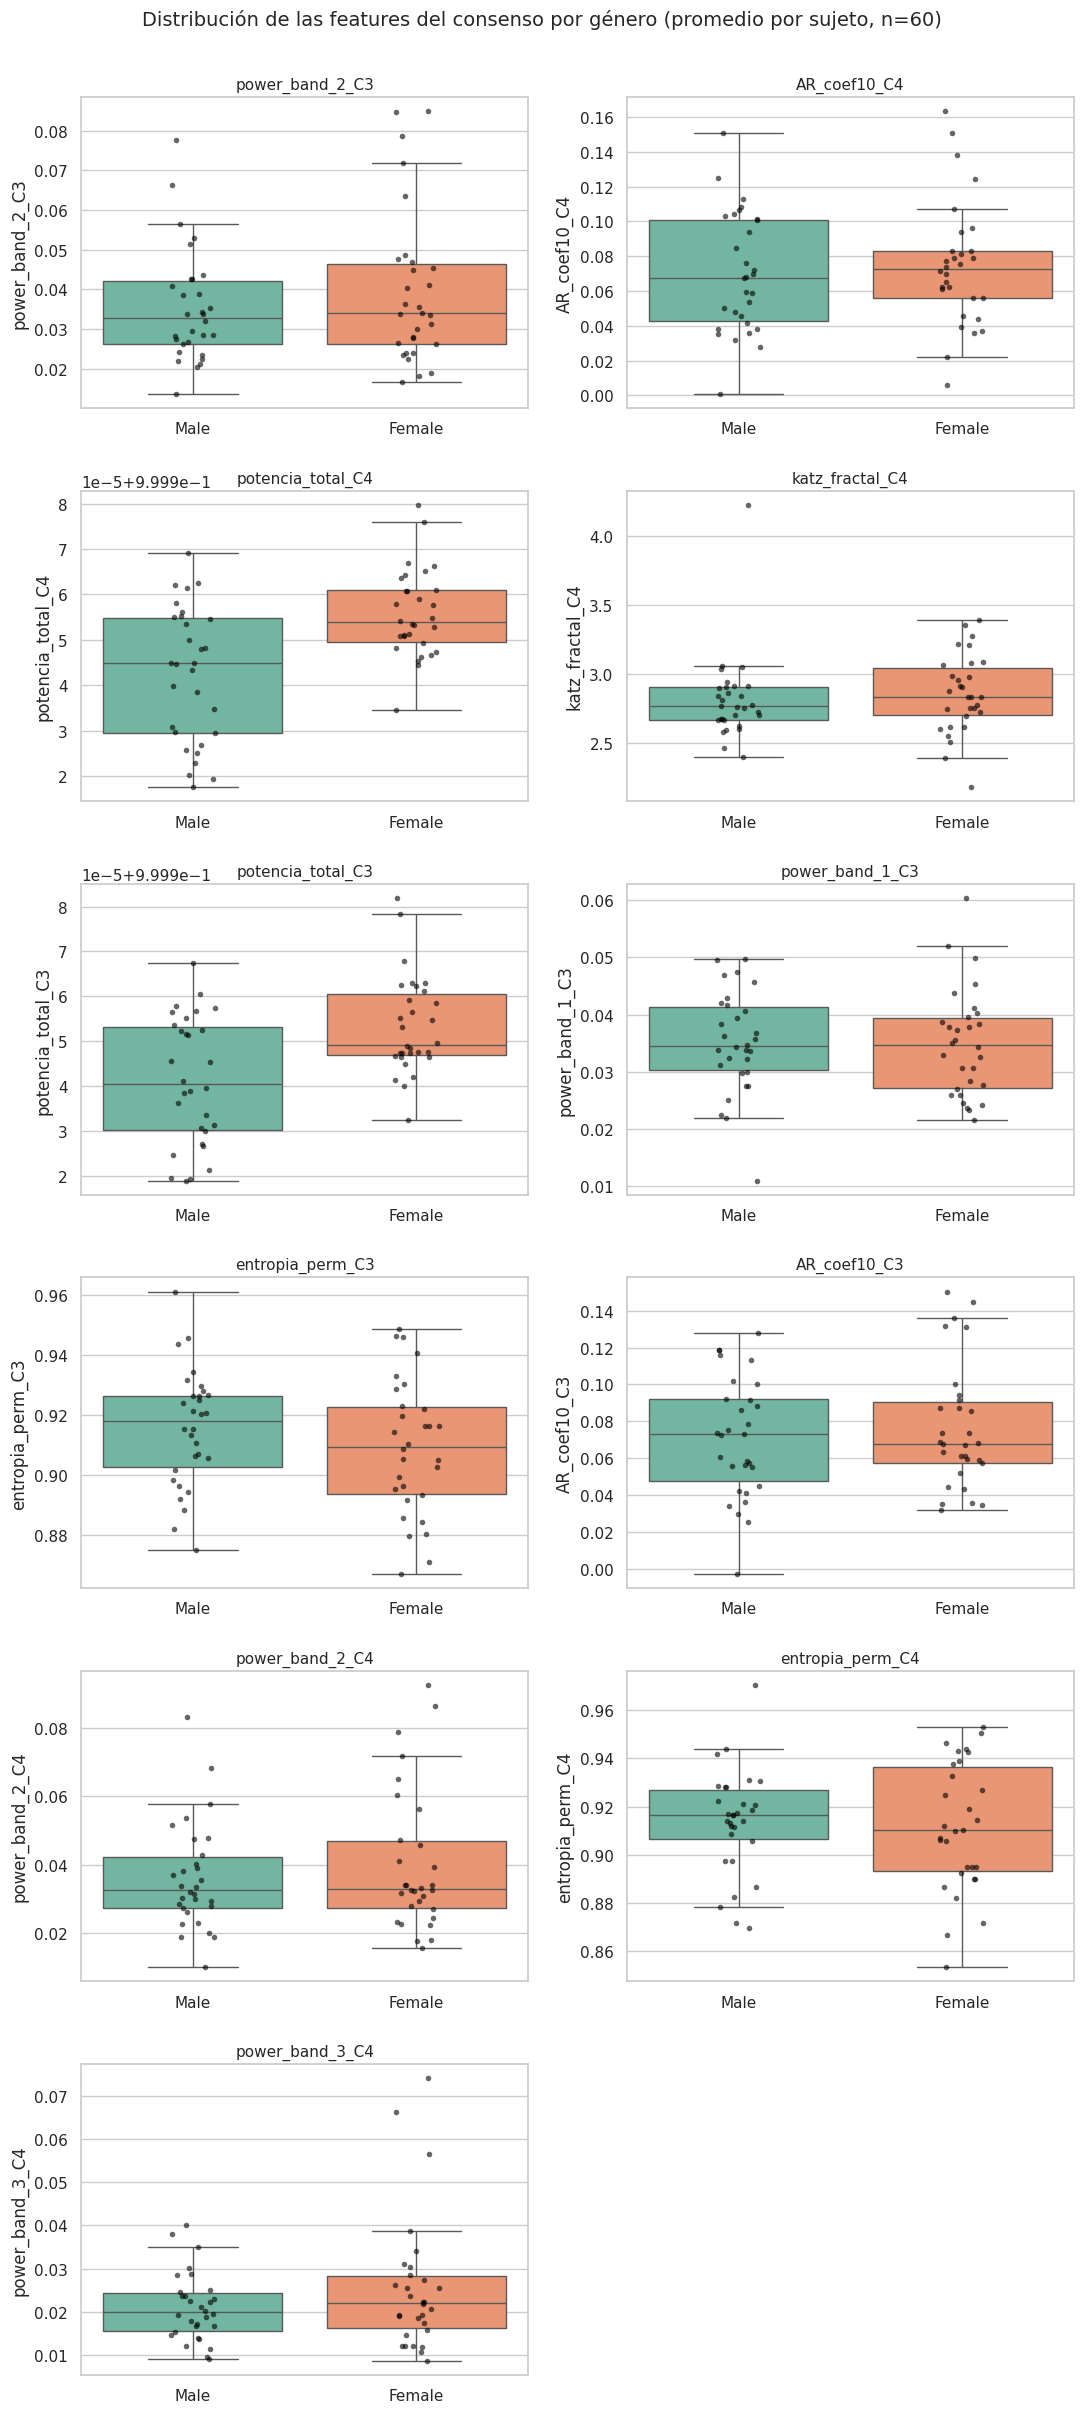

In [25]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

n_features = len(features_finales)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_finales):
    ax = axes[i]
    sns.boxplot(data=df_features_genero, x='genero', y=feature, showfliers=False,
                palette='Set2', ax=ax)
    sns.stripplot(data=df_features_genero, x='genero', y=feature, color='black',
                  alpha=0.6, jitter=True, ax=ax, size=4)
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')

# Ocultar ejes sobrantes si n_features es impar (queda un hueco en la grilla)
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribución de las features del consenso por género (promedio por sujeto, n=60)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()